In [1]:
import numpy as np
import math
import control
import matplotlib.pyplot as plt
from atm_std import rhoInterp, aInterp

In [2]:
# =========================== 1. PARAMÈTRES ET CONSTANTES DE L'AVION ET DU VOL ===========================

# Données de vol (Sujet 66)
Mach = 1.71              # Nombre de Mach
Altitude_ft = 15855      # Altitude en pieds

# Constantes de l'avion (page 5)
m = 8400.0               # Masse de l'avion (kg)
S = 34.0                 # Surface de référence (m^2)
lt = 7.86                # Longueur totale (m) (3/2 * 5.24 m)
l_ref = 5.24             # Longueur de référence (m)
rg = 2.65                # Rayon de giration (m)

# Constantes physiques
g0 = 9.81                # Accélération de la gravité (m/s^2)
R = 287.0                # Constante des gaz parfaits de l'air (J/kg/K)
gamma = 1.4              # Rapport de chaleurs spécifiques de l'air
T0 = 288.15              # Température standard au niveau de la mer (K)
P0 = 101325.0            # Pression standard au niveau de la mer (Pa)
lambda_atm = 0.0065      # Gradient de température standard (K/m)
ft_to_m = 0.3048         # Conversion pieds en mètres

# Coordonnées du centre de gravité (c)
c_pos = 0.52             # Centrage c (en % de la longueur totale)
xG = c_pos * lt          # Position du centre de gravité (m)

# Coefficients aérodynamiques lus des graphiques (ajustés pour Ma=1.71)
Cx0 = 0.029              # Drag coefficient for null incidence (Page 9)
Cz_alpha = 2.3           # Lift gradient coefficient (rad-1) (Page 10)
Cz_delta_m = 0.40        # Lift gradient coefficient w.r.t delta_m (rad-1) (Page 11)
delta_m_0 = -0.010       # Equilibrium fin deflection for null lift (rad) (Page 12)
alpha_0 = 0.010          # Incidence for null lift (rad) (Page 13)
f = 0.608                # Aerodynamic center of body and wings (Page 14)
f_delta = 0.90           # Aerodynamic center of fins (pitch axis) (Page 15)
k = 0.51                 # Polar coefficient (Page 16)
Cm_q = -0.27             # Damping coefficient (s/rad) (Page 17)

# Coefficients de position pour le moment de tangage
# Position du centre de poussée X / lt (f)
# Position du centre de poussée des gouvernes X_delta / lt (f_delta)
# Position du centre de gravité X_G / lt (c_pos)
X_F = f*lt
X_G = c_pos*lt
X_delta_f = f_delta*lt
X = X_F - X_G
Y = X_delta_f - X_G

In [3]:
# =========================== 2. FONCTION ATMOSPHÈRE US 76 ===========================
def get_air_density(altitude):
    """altitude en mètres"""
    return float(rhoInterp(altitude))

def get_sound_speed(altitude):
    """altitude en mètres"""
    return float(aInterp(altitude))

# Altitude en mètres
alt_m = Altitude_ft * ft_to_m

# Densité de l'air et vitesse du son via l'interpolation US76
rho = get_air_density(alt_m)
Vs  = get_sound_speed(alt_m)

# Vitesse avion et pression dynamique
Ve = Mach * Vs              # Vitesse de l'avion (m/s)
Q  = 0.5 * rho * Ve**2      # Pression dynamique (Pa)

print(f"\n--- CONDITIONS ATMOSPHÉRIQUES (Alt={Altitude_ft} ft, Ma={Mach}) ---")
print(f"Altitude: {alt_m:.2f} m")
print(f"Densité de l'air (rho): {rho:.4f} kg/m^3")
print(f"Vitesse du son (Vs): {Vs:.2f} m/s")
print(f"Vitesse avion (Ve): {Ve:.2f} m/s")
print(f"Pression dynamique (Q): {Q:.2f} Pa")
print("-" * 50)


--- CONDITIONS ATMOSPHÉRIQUES (Alt=15855 ft, Ma=1.71) ---
Altitude: 4832.60 m
Densité de l'air (rho): 0.7527 kg/m^3
Vitesse du son (Vs): 321.21 m/s
Vitesse avion (Ve): 549.27 m/s
Pression dynamique (Q): 113548.21 Pa
--------------------------------------------------


In [4]:
# =========================== 3. ALGORITHME DE CALCUL DU POINT D'ÉQUILIBRE ===========================

# Paramètres de l'algorithme
epsilon = 1e-6 # Seuil de convergence (Page 21)
max_iter = 100

# Initialisation (Page 21)
alpha_eq_i = 0.0 # alpha_eq_0
Fp_xeq_i = 0.0   # Fp_xeq_0

print("--- ALGORITHME D'ÉQUILIBRE ---")
for i in range(max_iter):
    # Étape 1 : Calcul de CZ_eq (Page 21)
    # L'équation d'équilibre de la portance (ou de la force Z) est :
    # mg - F_rho_x * sin(alpha) - Q S Cz = 0  (dans l'axe Z)
    # L'équation fournie sur la slide est pour la portance (axe Z)
    Cz_eq = (1 / (Q * S)) * (m * g0 - Fp_xeq_i * math.sin(alpha_eq_i))

    # Étape 2 : Calcul de Cx_eq et Cx_delta_m (Page 21)
    Cx_eq = Cx0 + k * Cz_eq**2
    Cx_delta_m = 2 * k * Cz_eq * Cz_delta_m

    # Étape 3 : Calcul de delta_m_eq (Page 21)

    try:
        numerator = (Cz_eq * X)
        denominator = (Cz_alpha * X + Cz_delta_m * (Y - X))
    
        num_dm = Cx_eq * math.sin(alpha_eq_i) + Cz_eq * math.cos(alpha_eq_i)
        den_dm = Cx_delta_m * math.sin(alpha_eq_i) + Cz_delta_m * math.cos(alpha_eq_i)
        

        ratio_moments = X / (Y - X)
        
        delta_m_eq = delta_m_0 - (num_dm / den_dm) * ratio_moments
        
    except ZeroDivisionError:
        print(f"Division par zéro à l'itération {i}. L'algorithme a échoué.")
        break
        
    # Étape 4 : Calcul de alpha_eq_i+1 (Page 21)
    alpha_eq_i_plus_1 = alpha_0 + (Cz_eq / Cz_alpha) - (Cz_delta_m / Cz_alpha) * delta_m_eq
    
    # Étape 5 : Calcul de Fp_xeq_i+1 (Page 21)
    Fp_xeq_i_plus_1 = (Q * S * Cx_eq) / math.cos(alpha_eq_i_plus_1)

    # Vérification de la convergence (Page 21)
    if abs(alpha_eq_i_plus_1 - alpha_eq_i) < epsilon:
        alpha_eq = alpha_eq_i_plus_1
        delta_m_eq_rad = delta_m_eq
        Fp_xeq = Fp_xeq_i_plus_1
        Cz_eq_final = Cz_eq
        Cx_eq_final = Cx_eq
        
        print(f"Convergence atteinte à l'itération {i+1}.")
        print(f"Alpha d'équilibre (alpha_eq): {alpha_eq:.6f} rad ({math.degrees(alpha_eq):.4f} deg)")
        print(f"Déflexion gouverne d'équilibre (delta_m_eq): {delta_m_eq_rad:.6f} rad ({math.degrees(delta_m_eq_rad):.4f} deg)")
        print(f"Force de poussée d'équilibre (Fp_xeq): {Fp_xeq:.2f} N")
        print(f"Coefficient de Portance d'équilibre (Cz_eq): {Cz_eq_final:.4f}")
        print(f"Coefficient de Traînée d'équilibre (Cx_eq): {Cx_eq_final:.4f}")
        break
        
    # Mise à jour pour la prochaine itération
    alpha_eq_i = alpha_eq_i_plus_1
    Fp_xeq_i = Fp_xeq_i_plus_1
    
else:
    print(f"L'algorithme n'a pas convergé après {max_iter} itérations.")
print("-" * 50)


--- ALGORITHME D'ÉQUILIBRE ---
Convergence atteinte à l'itération 4.
Alpha d'équilibre (alpha_eq): 0.023516 rad (1.3474 deg)
Déflexion gouverne d'équilibre (delta_m_eq): -0.026074 rad (-1.4939 deg)
Force de poussée d'équilibre (Fp_xeq): 112829.93 N
Coefficient de Portance d'équilibre (Cz_eq): 0.0207
Coefficient de Traînée d'équilibre (Cx_eq): 0.0292
--------------------------------------------------


In [5]:
# =========================== COEFFICIENTS DE STABILITÉ ===========================
# --- 1. CALCUL DES COEFFICIENTS ADIMENSIONNELS DE MOMENT ---

X_cg_ca = l_ref * (f - c_pos)
Y_cg_ca_fins = l_ref * (f_delta - c_pos)

Cm_alpha    = -Cz_alpha   * (f       - c_pos)
Cm_delta_m  = -Cz_delta_m * (f_delta - c_pos)

print("\n--- COEFFICIENTS DE MOMENT ADIMENSIONNELS ---")
print(f"Cm_alpha: {Cm_alpha:.4f}")
print(f"Cm_delta_m: {Cm_delta_m:.4f}")
print("-" * 50)

# --- 2. CALCUL DES COEFFICIENTS DU MODÈLE D'ÉTAT (FORMULES DU COURS) ---

# Moment d'inertie en tangage
I_y = m * rg**2

# Forces aérodynamiques à l'équilibre
L_eq = Q * S * Cz_eq_final          # Portance
D_eq = Q * S * Cx_eq_final          # Traînée
F_eq = math.sqrt(L_eq**2 + D_eq**2) # Résultante

gamma_eq = 0.0  # vol quasi horizontal

# === Coefficients de moment ===
m_alpha    = (Q * S * l_ref    * Cm_alpha)    / I_y          # [1/s^2]
m_q        = (Q * S * l_ref**2 * Cm_q)       / (Ve * I_y)    # [1/s]
m_delta_m  = (Q * S * l_ref    * Cm_delta_m) / I_y          # [1/s^2]

# === Coefficients de force Z ===
Z_alpha    = (F_eq * math.cos(alpha_eq)) / (m * Ve) + \
             (Q * S * Cz_alpha)          / (m * Ve)        # [1/s]
Z_delta_m  = (Q * S * Cz_delta_m)        / (m * Ve)        # [1/s]

print("\n--- COEFFICIENTS DU MODÈLE D'ÉTAT (FORMULES SIMPLIFIÉES) ---")
print(f"I_y (Moment d'inertie): {I_y:.2f} kg.m^2")
print(f"F_eq: {F_eq:.2f} N")
print(f"Z_alpha:   {Z_alpha:.4f} 1/s")
print(f"Z_delta_m: {Z_delta_m:.4f} 1/s")
print(f"m_alpha:   {m_alpha:.4f} 1/s^2")
print(f"m_q:       {m_q:.4f} 1/s")
print(f"m_delta_m: {m_delta_m:.4f} 1/s^2")
print("-" * 50)



--- COEFFICIENTS DE MOMENT ADIMENSIONNELS ---
Cm_alpha: -0.2024
Cm_delta_m: -0.1520
--------------------------------------------------

--- COEFFICIENTS DU MODÈLE D'ÉTAT (FORMULES SIMPLIFIÉES) ---
I_y (Moment d'inertie): 58989.00 kg.m^2
F_eq: 138144.00 N
Z_alpha:   1.9544 1/s
Z_delta_m: 0.3347 1/s
m_alpha:   -69.4113 1/s^2
m_q:       -0.8833 1/s
m_delta_m: -52.1270 1/s^2
--------------------------------------------------


Construction matrice A et B (taille 6x6)

In [6]:
# =========================== 4. CONSTRUCTION DES MATRICES D'ÉTAT (A et B) ===========================   
# 3) Coeffs Cx_alpha et Cx_delta_m via la polaire : Cx = Cx0 + k Cz^2
Cx_alpha   = 2 * k * Cz_eq_final * Cz_alpha      # dCx/dalpha
Cx_delta_m = 2 * k * Cz_eq_final * Cz_delta_m    # dCx/ddelta_m

X_V      = 2 * Q * S * Cx_eq_final / (m * Ve)                       # XV
X_alpha  = (F_eq * math.sin(alpha_eq)) / (m * Ve) + \
           (Q * S * Cx_alpha) / (m * Ve)                            # Xα
X_gamma  = g0 * math.cos(gamma_eq) / Ve                             # Xγ
X_delta_m = (Q * S * Cx_delta_m) / (m * Ve)                         # Xδm (peu utilisé ici)  

Z_V      = 2 * Q * S * Cz_eq_final / (m * Ve)                       # ou ≈ 2*g0/Ve
Z_gamma  = g0 * math.sin(gamma_eq) / Ve                             # ~ 0

# Matrice A (6x6) et B (6x1) pour X = (V, gamma, alpha, q, theta, z)^T
A6 = np.array([
    [-X_V,   -X_gamma,  -X_alpha,  0.0,   0.0,  0.0],
    [ Z_V,    0.0,       Z_alpha,  0.0,   0.0,  0.0],
    [-Z_V,    0.0,      -Z_alpha,  1.0,   0.0,  0.0],
    [ 0.0,    0.0,       m_alpha,  m_q,   0.0,  0.0],
    [ 0.0,    0.0,       0.0,      1.0,   0.0,  0.0],
    [ 0.0,    Ve,        0.0,      0.0,   0.0,  0.0]
])

B6 = np.array([
    [0.0],           # pas de terme en δm sur Vdot
    [Z_delta_m],     # γdot
    [-Z_delta_m],    # αdot
    [m_delta_m],     # qdot
    [0.0],           # θdot
    [0.0]            # zdot
])

print("\n===== MATRICE A6 (6x6) =====")
for row in A6:
    print("  ", ["{: .6e}".format(x) for x in row])

print("\n===== MATRICE B6 (6x1) =====")
for row in B6:
    print("  ", ["{: .6e}".format(x) for x in row])




===== MATRICE A6 (6x6) =====
   ['-4.889523e-02', '-1.785996e-02', '-4.125450e-02', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   [' 3.456989e-02', ' 0.000000e+00', ' 1.954439e+00', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   ['-3.456989e-02', ' 0.000000e+00', '-1.954439e+00', ' 1.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   [' 0.000000e+00', ' 0.000000e+00', '-6.941127e+01', '-8.833363e-01', ' 0.000000e+00', ' 0.000000e+00']
   [' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00', ' 1.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   [' 0.000000e+00', ' 5.492733e+02', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00']

===== MATRICE B6 (6x1) =====
   [' 0.000000e+00']
   [' 3.346967e-01']
   ['-3.346967e-01']
   ['-5.212704e+01']
   [' 0.000000e+00']
   [' 0.000000e+00']


Système 6×6, pôles, modes (short period / phugoïde)

In [7]:
# Système complet 6 états, sortie = tous les états
C6 = np.eye(6)
D6 = np.zeros((6, 1))
sys6 = control.ss(A6, B6, C6, D6)

state_names = ["V", "gamma", "alpha", "q", "theta", "z"]

print("\n===== PÔLES (VALEURS PROPRES) – MODÈLE 6x6 =====")
poles6 = sys6.poles()
for i, p in enumerate(poles6):
    print(f"p[{i}] = {p:.6e}")

print("\n===== ANALYSE DES MODES (ω_n, ζ) =====")
modes = []
for i, p in enumerate(poles6):
    sigma = np.real(p)
    omega = np.imag(p)
    omega_n = np.sqrt(sigma**2 + omega**2)
    zeta = -sigma / omega_n if omega_n != 0 else np.nan
    modes.append({"idx": i, "pole": p, "omega_n": omega_n, "zeta": zeta})

    print(f"Mode {i}:")
    print(f"  p = {p:.6e}")
    print(f"  ω_n = {omega_n:.6f} rad/s")
    print(f"  ζ   = {zeta:.6f}")
    print()

# Identification automatique des modes complexes (phugoïde / short period)
complex_modes = [m for m in modes if abs(np.imag(m["pole"])) > 1e-6]
complex_modes_sorted = sorted(complex_modes, key=lambda m: m["omega_n"])

if len(complex_modes_sorted) >= 4:
    phugoid_modes = complex_modes_sorted[0:2]      # plus petite fréquence naturelle
    short_period_modes = complex_modes_sorted[-2:] # plus grande fréquence naturelle

    print("===== MODE PHUGOÏDE (faible fréquence) =====")
    for m in phugoid_modes:
        print(f"  p = {m['pole']:.6e}, ω_n = {m['omega_n']:.4f}, ζ = {m['zeta']:.4f}")

    print("\n===== MODE PÉRIODE COURTE (haute fréquence) =====")
    for m in short_period_modes:
        print(f"  p = {m['pole']:.6e}, ω_n = {m['omega_n']:.4f}, ζ = {m['zeta']:.4f}")



===== PÔLES (VALEURS PROPRES) – MODÈLE 6x6 =====
p[0] = 0.000000e+00+0.000000e+00j
p[1] = 0.000000e+00+0.000000e+00j
p[2] = -1.418904e+00+8.314030e+00j
p[3] = -1.418904e+00-8.314030e+00j
p[4] = -2.443103e-02+2.359846e-03j
p[5] = -2.443103e-02-2.359846e-03j

===== ANALYSE DES MODES (ω_n, ζ) =====
Mode 0:
  p = 0.000000e+00+0.000000e+00j
  ω_n = 0.000000 rad/s
  ζ   = nan

Mode 1:
  p = 0.000000e+00+0.000000e+00j
  ω_n = 0.000000 rad/s
  ζ   = nan

Mode 2:
  p = -1.418904e+00+8.314030e+00j
  ω_n = 8.434238 rad/s
  ζ   = 0.168231

Mode 3:
  p = -1.418904e+00-8.314030e+00j
  ω_n = 8.434238 rad/s
  ζ   = 0.168231

Mode 4:
  p = -2.443103e-02+2.359846e-03j
  ω_n = 0.024545 rad/s
  ζ   = 0.995367

Mode 5:
  p = -2.443103e-02-2.359846e-03j
  ω_n = 0.024545 rad/s
  ζ   = 0.995367

===== MODE PHUGOÏDE (faible fréquence) =====
  p = -2.443103e-02+2.359846e-03j, ω_n = 0.0245, ζ = 0.9954
  p = -2.443103e-02-2.359846e-03j, ω_n = 0.0245, ζ = 0.9954

===== MODE PÉRIODE COURTE (haute fréquence) =====


Représentation d’état par mode équivalent de 2ᵉ ordre

In [8]:
# ==== Représentation canonique 2ᵉ ordre pour chaque mode ====

def second_order_A(omega_n, zeta):
    """Matrice A canonique pour un mode de 2e ordre (sans gain B/C)."""
    return np.array([
        [0.0,          1.0],
        [-omega_n**2, -2*zeta*omega_n]
    ])

# Exemple : prendre le premier pôle de chaque paire (phugoïde & short period)
if len(complex_modes_sorted) >= 4:
    ph_wn = phugoid_modes[0]["omega_n"]
    ph_z  = phugoid_modes[0]["zeta"]
    sp_wn = short_period_modes[0]["omega_n"]
    sp_z  = short_period_modes[0]["zeta"]

    A_ph = second_order_A(ph_wn, ph_z)
    B_ph = np.array([[0.0], [1.0]])   # gain arbitraire (à ajuster si besoin)
    C_ph = np.array([[1.0, 0.0]])     # sortie = état 1
    D_ph = np.array([[0.0]])

    A_sp = second_order_A(sp_wn, sp_z)
    B_sp = np.array([[0.0], [1.0]])
    C_sp = np.array([[1.0, 0.0]])
    D_sp = np.array([[0.0]])

    sys_ph = control.ss(A_ph, B_ph, C_ph, D_ph)
    sys_sp = control.ss(A_sp, B_sp, C_sp, D_sp)

    print("\nMatrice A du mode phugoïde (équivalent 2e ordre):")
    print(A_ph)
    print("\nMatrice A du mode période courte (équivalent 2e ordre):")
    print(A_sp)



Matrice A du mode phugoïde (équivalent 2e ordre):
[[ 0.00000000e+00  1.00000000e+00]
 [-6.02444092e-04 -4.88620597e-02]]

Matrice A du mode période courte (équivalent 2e ordre):
[[  0.           1.        ]
 [-71.13637723  -2.83780818]]


Fonctions de transfert δₘ → chaque variable (modèle 6×6)

In [9]:
# ==== Fonctions de transfert de δm vers chaque état (V, γ, α, q, θ, z) ====

G6 = control.ss2tf(sys6)  # 6 sorties, 1 entrée

print("\n===== FONCTIONS DE TRANSFERT δm -> état_i =====")
for i, name in enumerate(state_names):
    Gi = G6[i, 0]
    print(f"\nG_{name}(s) = {name}(s) / δm(s) :")
    print(Gi)




===== FONCTIONS DE TRANSFERT δm -> état_i =====

G_V(s) = V(s) / δm(s) :
<TransferFunction>: sys[3]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   2.22e-15 s^5 + 0.00783 s^4 + 2.157 s^3 + 1.405 s^2
  -----------------------------------------------------
  s^6 + 2.887 s^5 + 71.28 s^4 + 3.478 s^3 + 0.04286 s^2

G_gamma(s) = gamma(s) / δm(s) :
<TransferFunction>: sys[3]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[1]']

     0.3347 s^5 + 0.312 s^4 - 78.63 s^3 - 3.771 s^2
  -----------------------------------------------------
  s^6 + 2.887 s^5 + 71.28 s^4 + 3.478 s^3 + 0.04286 s^2

G_alpha(s) = alpha(s) / δm(s) :
<TransferFunction>: sys[3]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[2]']

    -0.3347 s^5 - 52.44 s^4 - 2.563 s^3 - 0.03218 s^2
  -----------------------------------------------------
  s^6 + 2.887 s^5 + 71.28 s^4 + 3.478 s^3 + 0.04286 s^2

G_q(s) = q(s) / δm(s) :
<TransferFunction>: sys[3]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[3]']

    -52.13 s^5 - 81.2 s

Réponses indicielle pour chaque variable (6×6)

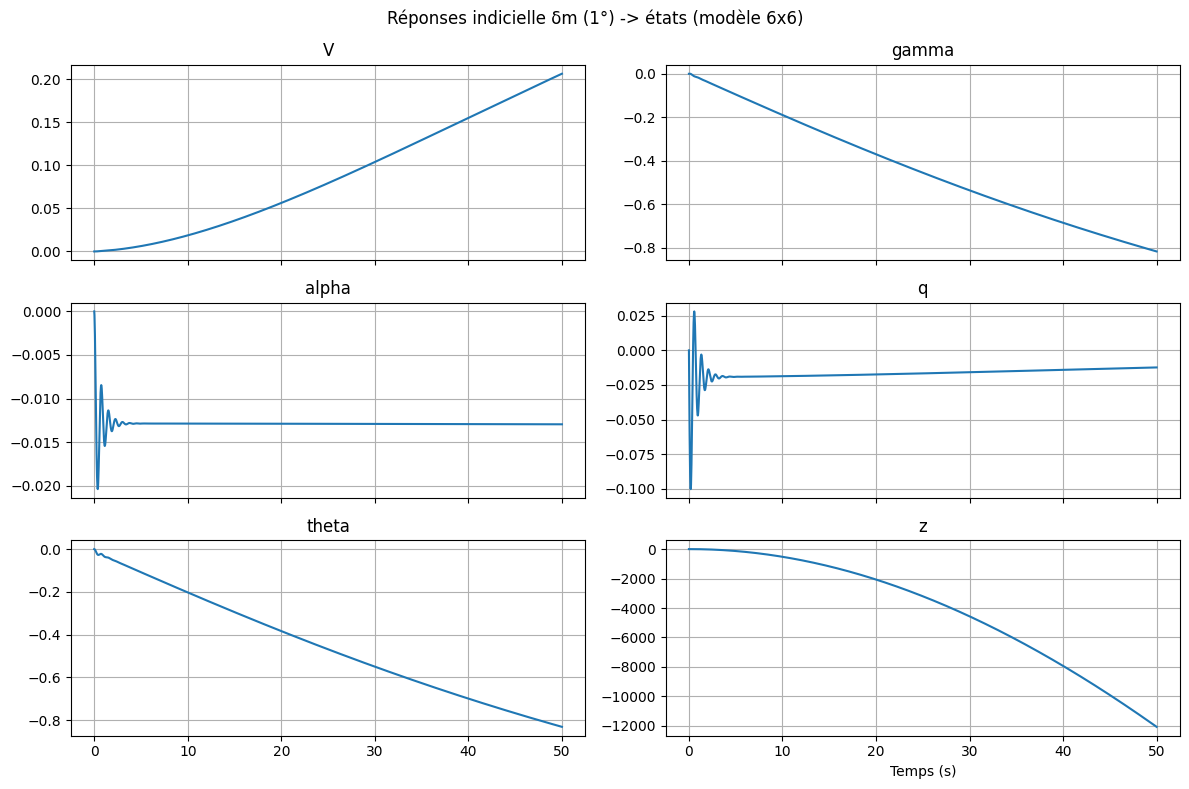

In [10]:
# amplitude de l'échelon sur δm : 1° = 0.01745 rad
delta_step = 1.0 * np.pi / 180.0

t = np.linspace(0, 50, 2000)

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for i, name in enumerate(state_names):
    # sortie = état i uniquement
    Ci = np.zeros((1, 6))
    Ci[0, i] = 1.0
    Di = np.zeros((1, 1))
    sys_i = control.ss(A6, B6, Ci, Di)

    tout, yout = control.step_response(sys_i, T=t)
    yout = np.squeeze(yout) * delta_step  # on applique l'amplitude de l'échelon

    ax = axes[i]
    ax.plot(tout, yout)
    ax.set_title(name)
    ax.grid(True)

axes[-1].set_xlabel("Temps (s)")
fig.suptitle("Réponses indicielle δm (1°) -> états (modèle 6x6)")
plt.tight_layout()
plt.show()


Matrice A et B (taille 5x5)

In [11]:
# Matrice A (5x5) et B (5x1) pour X = (gamma, alpha, q, theta, z)^T
A5 = A6[1:, 1:]   # enlève la première ligne/colonne (V)
B5 = B6[1:, :]    # enlève la première ligne de B

# Matrice de sortie pour q (3e état de [γ, α, q, θ, z])
C_q = np.zeros((1, 5))
C_q[0, 2] = 1.0  
D_q = 0


print("\n===== MATRICE A5 (5x5) =====")
for row in A5:
    print("  ", ["{: .6e}".format(x) for x in row])

print("\n===== MATRICE B5 (5x1) =====")
for row in B5:
    print("  ", ["{: .6e}".format(x) for x in row])

print("\n===== MATRICE C_q (1x5) =====")
print(["{: .6e}".format(x) for x in C_q[0]])

print("\n===== MATRICE D_q (1x1) =====")
print(D_q)


===== MATRICE A5 (5x5) =====
   [' 0.000000e+00', ' 1.954439e+00', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   [' 0.000000e+00', '-1.954439e+00', ' 1.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   [' 0.000000e+00', '-6.941127e+01', '-8.833363e-01', ' 0.000000e+00', ' 0.000000e+00']
   [' 0.000000e+00', ' 0.000000e+00', ' 1.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   [' 5.492733e+02', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00']

===== MATRICE B5 (5x1) =====
   [' 3.346967e-01']
   ['-3.346967e-01']
   ['-5.212704e+01']
   [' 0.000000e+00']
   [' 0.000000e+00']

===== MATRICE C_q (1x5) =====
[' 0.000000e+00', ' 0.000000e+00', ' 1.000000e+00', ' 0.000000e+00', ' 0.000000e+00']

===== MATRICE D_q (1x1) =====
0


Systèmes d’état et pôles (phugoïde / période courte)

In [12]:
state_names_5 = ["gamma", "alpha", "q", "theta", "z"]

# Système complet (sortie = tous les états)
C5_full = np.eye(5)
D5_full = np.zeros((5, 1))
sys5_full = control.ss(A5, B5, C5_full, D5_full)

# Système SISO pour q uniquement
sys5_q = control.ss(A5, B5, C_q, D_q)

print("\n===== PÔLES (VALEURS PROPRES – MODÈLE 5x5) =====")
poles5 = sys5_full.poles()
for i, p in enumerate(poles5):
    print(f"p[{i}] = {p:.6e}")

print("\n===== ANALYSE DES MODES (ω_n, ζ) =====")
modes5 = []
for i, p in enumerate(poles5):
    sigma = np.real(p)
    omega = np.imag(p)
    omega_n = np.sqrt(sigma**2 + omega**2)
    zeta = -sigma / omega_n if omega_n != 0 else np.nan

    modes5.append({"idx": i, "pole": p, "omega_n": omega_n, "zeta": zeta})

    print(f"Mode {i}:")
    print(f"  p = {p:.6e}")
    print(f"  ω_n = {omega_n:.6f} rad/s")
    print(f"  ζ   = {zeta:.6f}")
    print()

# Identification des deux paires complexes : phugoïde (faible ω_n) et période courte (forte ω_n)
complex_modes5 = [m for m in modes5 if abs(np.imag(m["pole"])) > 1e-6]
complex_modes5_sorted = sorted(complex_modes5, key=lambda m: m["omega_n"])

if len(complex_modes5_sorted) >= 4:
    phugoid_modes = complex_modes5_sorted[0:2]      # plus petite fréquence
    short_period_modes = complex_modes5_sorted[-2:] # plus grande fréquence

    print("===== MODE PHUGOÏDE (faible fréquence) =====")
    for m in phugoid_modes:
        print(f"  p = {m['pole']:.6e}, ω_n = {m['omega_n']:.4f}, ζ = {m['zeta']:.4f}")

    print("\n===== MODE PÉRIODE COURTE (haute fréquence) =====")
    for m in short_period_modes:
        print(f"  p = {m['pole']:.6e}, ω_n = {m['omega_n']:.4f}, ζ = {m['zeta']:.4f}")



===== PÔLES (VALEURS PROPRES – MODÈLE 5x5) =====
p[0] = 0.000000e+00+0.000000e+00j
p[1] = 0.000000e+00+0.000000e+00j
p[2] = 0.000000e+00+0.000000e+00j
p[3] = -1.418888e+00+8.314112e+00j
p[4] = -1.418888e+00-8.314112e+00j

===== ANALYSE DES MODES (ω_n, ζ) =====
Mode 0:
  p = 0.000000e+00+0.000000e+00j
  ω_n = 0.000000 rad/s
  ζ   = nan

Mode 1:
  p = 0.000000e+00+0.000000e+00j
  ω_n = 0.000000 rad/s
  ζ   = nan

Mode 2:
  p = 0.000000e+00+0.000000e+00j
  ω_n = 0.000000 rad/s
  ζ   = nan

Mode 3:
  p = -1.418888e+00+8.314112e+00j
  ω_n = 8.434317 rad/s
  ζ   = 0.168228

Mode 4:
  p = -1.418888e+00-8.314112e+00j
  ω_n = 8.434317 rad/s
  ζ   = 0.168228



Représentation d’état par mode (2ᵉ ordre équivalent)

In [13]:
def second_order_ss(omega_n, zeta):
    """
    Renvoie (A,B,C,D) d'un système 2e ordre standard :
    xdot = [0 1; -omega_n^2 -2*zeta*omega_n] x + [0;1] u
    y = [1 0] x
    """
    A = np.array([[0.0, 1.0],
                  [-omega_n**2, -2*zeta*omega_n]])
    B = np.array([[0.0],
                  [1.0]])
    C = np.array([[1.0, 0.0]])
    D = np.array([[0.0]])
    return A, B, C, D

if len(complex_modes5_sorted) >= 4:
    # On prend le premier pôle de chaque paire (les conjugués ont même ω_n, ζ)
    ph_wn = phugoid_modes[0]["omega_n"]
    ph_z  = phugoid_modes[0]["zeta"]
    sp_wn = short_period_modes[0]["omega_n"]
    sp_z  = short_period_modes[0]["zeta"]

    A_ph, B_ph, C_ph, D_ph = second_order_ss(ph_wn, ph_z)
    A_sp, B_sp, C_sp, D_sp = second_order_ss(sp_wn, sp_z)

    sys_ph = control.ss(A_ph, B_ph, C_ph, D_ph)
    sys_sp = control.ss(A_sp, B_sp, C_sp, D_sp)

    print("\n===== MATRICE A DU MODE PHUGOÏDE (2x2) =====")
    print(A_ph)
    print("\n===== MATRICE A DU MODE PÉRIODE COURTE (2x2) =====")
    print(A_sp)

Fonctions de transfert δₘ → chaque variable (modèle 5×5)

In [14]:
# ==== Fonctions de transfert (MIMO) δm -> [γ, α, q, θ, z] ====
G5 = control.ss2tf(sys5_full)  # 5 sorties, 1 entrée

print("\n===== FONCTIONS DE TRANSFERT δm -> état_i (modèle 5x5) =====")
for i, name in enumerate(state_names_5):
    Gi = G5[i, 0]   # sortie i, unique entrée 0
    print(f"\nG_{name}(s) = {name}(s) / δm(s) :")
    print(Gi)



===== FONCTIONS DE TRANSFERT δm -> état_i (modèle 5x5) =====

G_gamma(s) = gamma(s) / δm(s) :
<TransferFunction>: sys[12]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.3347 s^4 + 0.2956 s^3 - 78.65 s^2
  -----------------------------------
      s^5 + 2.838 s^4 + 71.14 s^3

G_alpha(s) = alpha(s) / δm(s) :
<TransferFunction>: sys[12]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[1]']

    -0.3347 s^4 - 52.42 s^3
  ---------------------------
  s^5 + 2.838 s^4 + 71.14 s^3

G_q(s) = q(s) / δm(s) :
<TransferFunction>: sys[12]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[2]']

    -52.13 s^4 - 78.65 s^3
  ---------------------------
  s^5 + 2.838 s^4 + 71.14 s^3

G_theta(s) = theta(s) / δm(s) :
<TransferFunction>: sys[12]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[3]']

  -6.217e-15 s^4 - 52.13 s^3 - 78.65 s^2
  --------------------------------------
       s^5 + 2.838 s^4 + 71.14 s^3

G_z(s) = z(s) / δm(s) :
<TransferFunction>: sys[12]$indexed
Inputs (1): ['u[0]']
Outputs (1

Réponse indicielle δₘ → q (mode période courte dominant)

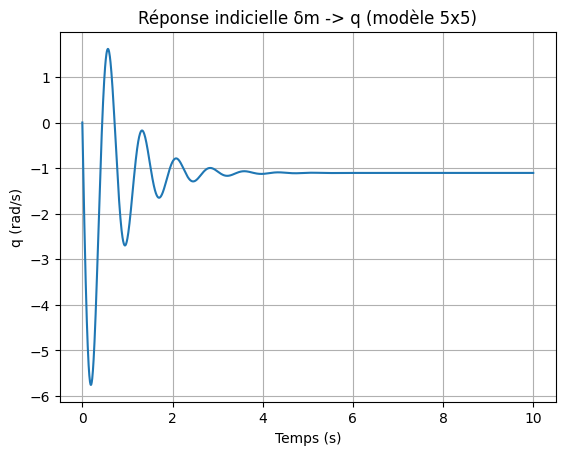

In [15]:
# ===== Réponse indicielle δm -> q =====

t = np.linspace(0, 10, 2000)  # 10 s suffisent pour voir la période courte
t_out, y_out = control.step_response(sys5_q, T=t)
y_out = np.squeeze(y_out)     # (N,) au lieu de (1,N)

plt.figure()
plt.plot(t_out, y_out)
plt.title("Réponse indicielle δm -> q (modèle 5x5)")
plt.xlabel("Temps (s)")
plt.ylabel("q (rad/s)")
plt.grid(True)
plt.show()


Réponses indicielles δₘ → chaque état (γ, α, q, θ, z)

y_out.shape = (5, 3000)


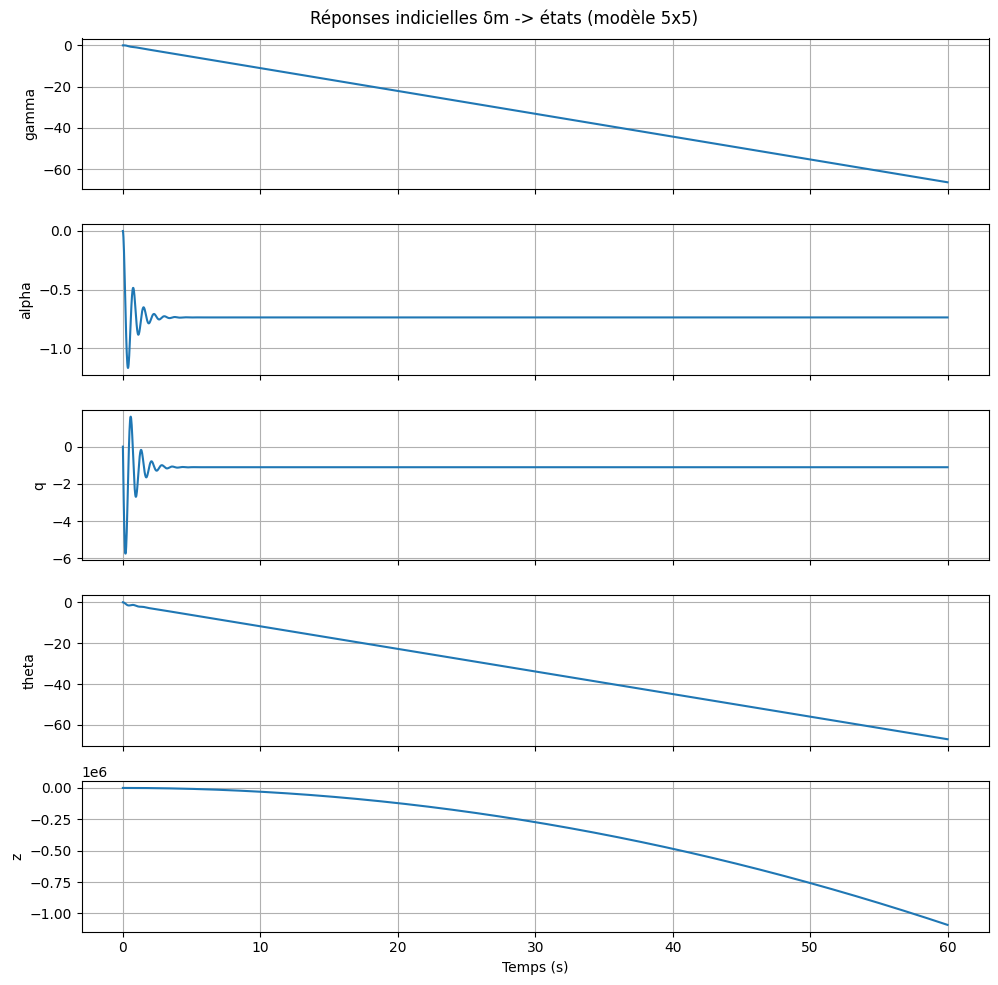

In [16]:
# ===== Réponse indicielle δm -> [γ, α, q, θ, z] =====

t = np.linspace(0, 60, 3000)  # 60 s pour voir aussi la phugoïde
t_out, y_out = control.step_response(sys5_full, T=t)
y_out = np.squeeze(y_out)     # (5,N)

print("y_out.shape =", y_out.shape)  # devrait être (5, N)

fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)

for i, name in enumerate(state_names_5):
    axes[i].plot(t_out, y_out[i, :])
    axes[i].set_ylabel(name)
    axes[i].grid(True)

axes[-1].set_xlabel("Temps (s)")
fig.suptitle("Réponses indicielles δm -> états (modèle 5x5)")
plt.tight_layout()
plt.show()


SYNTHÈSE DU CONTRÔLEUR Q

In [17]:
#!pip install ipympl[all]
import sisopy31
import ipympl
sys_q_open_loop = control.ss(A5, B5, C_q, D_q)
sys_q_ol = control.ss2tf(sys_q_open_loop)
#sisopy31.sisotool(sys_q_ol)


--- SYNTHÈSE BOUCLE Q (q feedback loop) ---
Gain optimisé Kr: -0.2655
Facteur d'amortissement atteint (xi): 0.5000 (Cible: 0.65)
Pulsation propre (omega_n): 1.0000 rad/s

MATRICE D'ÉTAT EN BOUCLE FERMÉE (Ak_opt):
[[  0.       1.9544   0.0889   0.       0.    ]
 [  0.      -1.9544   0.9111   0.       0.    ]
 [  0.     -69.4113 -14.7231   0.       0.    ]
 [  0.       0.       1.       0.       0.    ]
 [549.2733   0.       0.       0.       0.    ]]

MATRICE DE COMMANDE EN BOUCLE FERMÉE (Bk_opt):
[[-0.0889]
 [ 0.0889]
 [13.8397]
 [-0.    ]
 [-0.    ]]


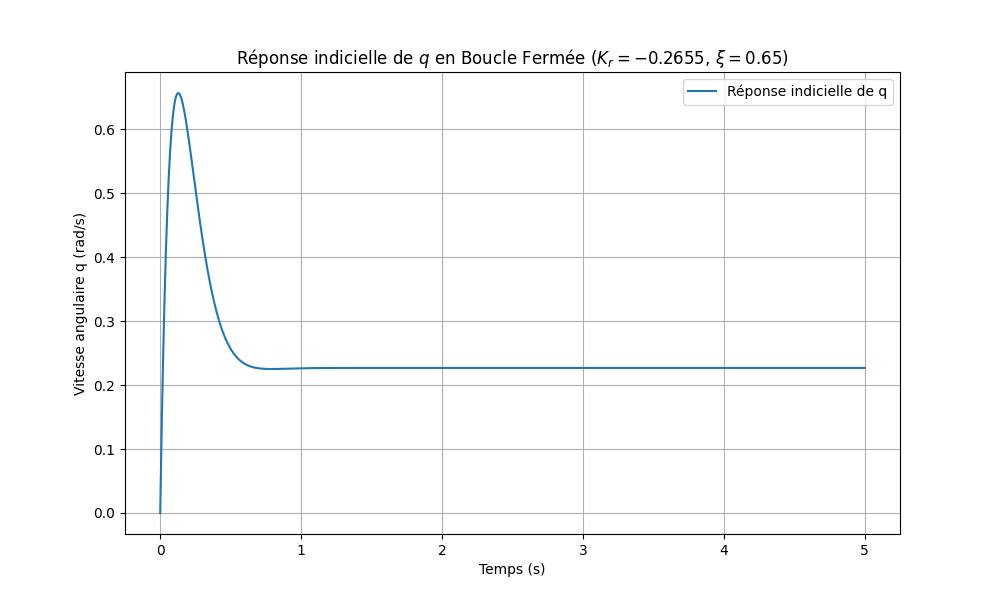

In [18]:
# Objectif: Facteur d'amortissement en boucle fermée xi_cl = 0.65 pour le mode Période Courte.
xi_target_q = 0.65
Kr_optimized = -0.2655

# Initialiser les variables avant la boucle pour éviter NameError
xi_final_q = 0.5
omega_n_final_q = 1.0
poles_cl_short_period = -0.5 + 1.0j

# Matrice de sortie pour q (q est la 3ème variable d'état, index 2)
C_q = np.array([[0.0, 0.0, 1.0, 0.0, 0.0]])
D_q = np.zeros((1, 1))

# Recherche du gain Kr qui donne xi_cl = 0.65 (balayage)
Kr_list = np.linspace(0.1, 5.0, 500) 
min_diff_q = float('inf')

for Kr_test in Kr_list:
    # Matrices en Boucle Fermée pour q: Ak = A - Kr * B * Cq
    Ak = A5 - Kr_test * B5 @ C_q
    
    sys_cl_q_analysis = control.ss(Ak, B5, C_q, D_q)
    poles_cl = control.poles(sys_cl_q_analysis)
    
    poles_complex = [p for p in poles_cl if np.imag(p) != 0.0 and np.real(p) < 0]
    if poles_complex:
        p_cl = sorted(poles_complex, key=np.abs, reverse=True)[0]
        p_real = np.real(p_cl)
        omega_n = np.abs(p_cl)
        xi = -p_real / omega_n
        
        diff = np.abs(xi - xi_target_q)
        
        if diff < min_diff_q:
            min_diff_q = diff
            Kr_optimized = Kr_test
            xi_final_q = xi
            omega_n_final_q = omega_n
            poles_cl_short_period = p_cl
            
# Matrice d'état finale en boucle fermée pour Kr
Ak_opt = A5 - Kr_optimized * B5 @ C_q
Bk_opt = Kr_optimized * B5
sys_cl_q_final = control.ss(Ak_opt, Bk_opt, C_q, D_q)
poles_cl_final = control.poles(sys_cl_q_final)

# Affichage des résultats
print("\n--- SYNTHÈSE BOUCLE Q (q feedback loop) ---")
print(f"Gain optimisé Kr: {Kr_optimized:.4f}")
print(f"Facteur d'amortissement atteint (xi): {xi_final_q:.4f} (Cible: {xi_target_q})")
print(f"Pulsation propre (omega_n): {omega_n_final_q:.4f} rad/s")
print("\nMATRICE D'ÉTAT EN BOUCLE FERMÉE (Ak_opt):")
print(Ak_opt.round(4))
print("\nMATRICE DE COMMANDE EN BOUCLE FERMÉE (Bk_opt):")
print(Bk_opt.round(4))

# Tracé de la réponse indicielle
T_sim_q = 5.0 # 5s suffisent pour la période courte
T_out_q, Y_out_q = control.step_response(sys_cl_q_final, T=np.linspace(0, T_sim_q, 500))
Y_out_q = np.squeeze(Y_out_q)  # Reshape to 1D array

plt.figure(figsize=(10, 6))
plt.plot(T_out_q, Y_out_q, label='Réponse indicielle de q')
plt.title(f'Réponse indicielle de $q$ en Boucle Fermée ($K_r = {Kr_optimized:.4f}$, $\\xi=0.65$)')
plt.xlabel('Temps (s)'); plt.ylabel('Vitesse angulaire q (rad/s)')
plt.grid(); plt.legend(); plt.show()


In [19]:
import numpy as np
import math
import control
import matplotlib.pyplot as plt
from atm_std import rhoInterp, aInterp

In [20]:
# =========================== 1. PARAMÈTRES ET CONSTANTES DE L'AVION ET DU VOL ===========================

# Données de vol (Sujet 66)
Mach = 1.71              # Nombre de Mach
Altitude_ft = 15855      # Altitude en pieds

# Constantes de l'avion (page 5)
m = 8400.0               # Masse de l'avion (kg)
S = 34.0                 # Surface de référence (m^2)
lt = 7.86                # Longueur totale (m) (3/2 * 5.24 m)
l_ref = 5.24             # Longueur de référence (m)
rg = 2.65                # Rayon de giration (m)

# Constantes physiques
g0 = 9.81                # Accélération de la gravité (m/s^2)
R = 287.0                # Constante des gaz parfaits de l'air (J/kg/K)
gamma = 1.4              # Rapport de chaleurs spécifiques de l'air
T0 = 288.15              # Température standard au niveau de la mer (K)
P0 = 101325.0            # Pression standard au niveau de la mer (Pa)
lambda_atm = 0.0065      # Gradient de température standard (K/m)
ft_to_m = 0.3048         # Conversion pieds en mètres

# Coordonnées du centre de gravité (c)
c_pos = 0.52             # Centrage c (en % de la longueur totale)
xG = c_pos * lt          # Position du centre de gravité (m)

# Coefficients aérodynamiques lus des graphiques (ajustés pour Ma=1.71)
Cx0 = 0.029              # Drag coefficient for null incidence (Page 9)
Cz_alpha = 2.3           # Lift gradient coefficient (rad-1) (Page 10)
Cz_delta_m = 0.40        # Lift gradient coefficient w.r.t delta_m (rad-1) (Page 11)
delta_m_0 = -0.010       # Equilibrium fin deflection for null lift (rad) (Page 12)
alpha_0 = 0.010          # Incidence for null lift (rad) (Page 13)
f = 0.608                # Aerodynamic center of body and wings (Page 14)
f_delta = 0.90           # Aerodynamic center of fins (pitch axis) (Page 15)
k = 0.51                 # Polar coefficient (Page 16)
Cm_q = -0.27             # Damping coefficient (s/rad) (Page 17)

# Coefficients de position pour le moment de tangage
# Position du centre de poussée X / lt (f)
# Position du centre de poussée des gouvernes X_delta / lt (f_delta)
# Position du centre de gravité X_G / lt (c_pos)
X_F = f*lt
X_G = c_pos*lt
X_delta_f = f_delta*lt
X = X_F - X_G
Y = X_delta_f - X_G

In [21]:
# =========================== 2. FONCTION ATMOSPHÈRE US 76 ===========================
def get_air_density(altitude):
    """altitude en mètres"""
    return float(rhoInterp(altitude))

def get_sound_speed(altitude):
    """altitude en mètres"""
    return float(aInterp(altitude))

# Altitude en mètres
alt_m = Altitude_ft * ft_to_m

# Densité de l'air et vitesse du son via l'interpolation US76
rho = get_air_density(alt_m)
Vs  = get_sound_speed(alt_m)

# Vitesse avion et pression dynamique
Ve = Mach * Vs              # Vitesse de l'avion (m/s)
Q  = 0.5 * rho * Ve**2      # Pression dynamique (Pa)

print(f"\n--- CONDITIONS ATMOSPHÉRIQUES (Alt={Altitude_ft} ft, Ma={Mach}) ---")
print(f"Altitude: {alt_m:.2f} m")
print(f"Densité de l'air (rho): {rho:.4f} kg/m^3")
print(f"Vitesse du son (Vs): {Vs:.2f} m/s")
print(f"Vitesse avion (Ve): {Ve:.2f} m/s")
print(f"Pression dynamique (Q): {Q:.2f} Pa")
print("-" * 50)


--- CONDITIONS ATMOSPHÉRIQUES (Alt=15855 ft, Ma=1.71) ---
Altitude: 4832.60 m
Densité de l'air (rho): 0.7527 kg/m^3
Vitesse du son (Vs): 321.21 m/s
Vitesse avion (Ve): 549.27 m/s
Pression dynamique (Q): 113548.21 Pa
--------------------------------------------------


In [22]:
# =========================== 3. ALGORITHME DE CALCUL DU POINT D'ÉQUILIBRE ===========================

# Paramètres de l'algorithme
epsilon = 1e-6 # Seuil de convergence (Page 21)
max_iter = 100

# Initialisation (Page 21)
alpha_eq_i = 0.0 # alpha_eq_0
Fp_xeq_i = 0.0   # Fp_xeq_0

print("--- ALGORITHME D'ÉQUILIBRE ---")
for i in range(max_iter):
    # Étape 1 : Calcul de CZ_eq (Page 21)
    # L'équation d'équilibre de la portance (ou de la force Z) est :
    # mg - F_rho_x * sin(alpha) - Q S Cz = 0  (dans l'axe Z)
    # L'équation fournie sur la slide est pour la portance (axe Z)
    Cz_eq = (1 / (Q * S)) * (m * g0 - Fp_xeq_i * math.sin(alpha_eq_i))

    # Étape 2 : Calcul de Cx_eq et Cx_delta_m (Page 21)
    Cx_eq = Cx0 + k * Cz_eq**2
    Cx_delta_m = 2 * k * Cz_eq * Cz_delta_m

    # Étape 3 : Calcul de delta_m_eq (Page 21)

    try:
        numerator = (Cz_eq * X)
        denominator = (Cz_alpha * X + Cz_delta_m * (Y - X))
    
        num_dm = Cx_eq * math.sin(alpha_eq_i) + Cz_eq * math.cos(alpha_eq_i)
        den_dm = Cx_delta_m * math.sin(alpha_eq_i) + Cz_delta_m * math.cos(alpha_eq_i)
        

        ratio_moments = X / (Y - X)
        
        delta_m_eq = delta_m_0 - (num_dm / den_dm) * ratio_moments
        
    except ZeroDivisionError:
        print(f"Division par zéro à l'itération {i}. L'algorithme a échoué.")
        break
        
    # Étape 4 : Calcul de alpha_eq_i+1 (Page 21)
    alpha_eq_i_plus_1 = alpha_0 + (Cz_eq / Cz_alpha) - (Cz_delta_m / Cz_alpha) * delta_m_eq
    
    # Étape 5 : Calcul de Fp_xeq_i+1 (Page 21)
    Fp_xeq_i_plus_1 = (Q * S * Cx_eq) / math.cos(alpha_eq_i_plus_1)

    # Vérification de la convergence (Page 21)
    if abs(alpha_eq_i_plus_1 - alpha_eq_i) < epsilon:
        alpha_eq = alpha_eq_i_plus_1
        delta_m_eq_rad = delta_m_eq
        Fp_xeq = Fp_xeq_i_plus_1
        Cz_eq_final = Cz_eq
        Cx_eq_final = Cx_eq
        
        print(f"Convergence atteinte à l'itération {i+1}.")
        print(f"Alpha d'équilibre (alpha_eq): {alpha_eq:.6f} rad ({math.degrees(alpha_eq):.4f} deg)")
        print(f"Déflexion gouverne d'équilibre (delta_m_eq): {delta_m_eq_rad:.6f} rad ({math.degrees(delta_m_eq_rad):.4f} deg)")
        print(f"Force de poussée d'équilibre (Fp_xeq): {Fp_xeq:.2f} N")
        print(f"Coefficient de Portance d'équilibre (Cz_eq): {Cz_eq_final:.4f}")
        print(f"Coefficient de Traînée d'équilibre (Cx_eq): {Cx_eq_final:.4f}")
        break
        
    # Mise à jour pour la prochaine itération
    alpha_eq_i = alpha_eq_i_plus_1
    Fp_xeq_i = Fp_xeq_i_plus_1
    
else:
    print(f"L'algorithme n'a pas convergé après {max_iter} itérations.")
print("-" * 50)


--- ALGORITHME D'ÉQUILIBRE ---
Convergence atteinte à l'itération 4.
Alpha d'équilibre (alpha_eq): 0.023516 rad (1.3474 deg)
Déflexion gouverne d'équilibre (delta_m_eq): -0.026074 rad (-1.4939 deg)
Force de poussée d'équilibre (Fp_xeq): 112829.93 N
Coefficient de Portance d'équilibre (Cz_eq): 0.0207
Coefficient de Traînée d'équilibre (Cx_eq): 0.0292
--------------------------------------------------


In [23]:
# =========================== COEFFICIENTS DE STABILITÉ ===========================
# --- 1. CALCUL DES COEFFICIENTS ADIMENSIONNELS DE MOMENT ---

X_cg_ca = l_ref * (f - c_pos)
Y_cg_ca_fins = l_ref * (f_delta - c_pos)

Cm_alpha    = -Cz_alpha   * (f       - c_pos)
Cm_delta_m  = -Cz_delta_m * (f_delta - c_pos)

print("\n--- COEFFICIENTS DE MOMENT ADIMENSIONNELS ---")
print(f"Cm_alpha: {Cm_alpha:.4f}")
print(f"Cm_delta_m: {Cm_delta_m:.4f}")
print("-" * 50)

# --- 2. CALCUL DES COEFFICIENTS DU MODÈLE D'ÉTAT (FORMULES DU COURS) ---

# Moment d'inertie en tangage
I_y = m * rg**2

# Forces aérodynamiques à l'équilibre
L_eq = Q * S * Cz_eq_final          # Portance
D_eq = Q * S * Cx_eq_final          # Traînée
F_eq = math.sqrt(L_eq**2 + D_eq**2) # Résultante

gamma_eq = 0.0  # vol quasi horizontal

# === Coefficients de moment ===
m_alpha    = (Q * S * l_ref    * Cm_alpha)    / I_y          # [1/s^2]
m_q        = (Q * S * l_ref**2 * Cm_q)       / (Ve * I_y)    # [1/s]
m_delta_m  = (Q * S * l_ref    * Cm_delta_m) / I_y          # [1/s^2]

# === Coefficients de force Z ===
Z_alpha    = (F_eq * math.cos(alpha_eq)) / (m * Ve) + \
             (Q * S * Cz_alpha)          / (m * Ve)        # [1/s]
Z_delta_m  = (Q * S * Cz_delta_m)        / (m * Ve)        # [1/s]

print("\n--- COEFFICIENTS DU MODÈLE D'ÉTAT (FORMULES SIMPLIFIÉES) ---")
print(f"I_y (Moment d'inertie): {I_y:.2f} kg.m^2")
print(f"F_eq: {F_eq:.2f} N")
print(f"Z_alpha:   {Z_alpha:.4f} 1/s")
print(f"Z_delta_m: {Z_delta_m:.4f} 1/s")
print(f"m_alpha:   {m_alpha:.4f} 1/s^2")
print(f"m_q:       {m_q:.4f} 1/s")
print(f"m_delta_m: {m_delta_m:.4f} 1/s^2")
print("-" * 50)



--- COEFFICIENTS DE MOMENT ADIMENSIONNELS ---
Cm_alpha: -0.2024
Cm_delta_m: -0.1520
--------------------------------------------------

--- COEFFICIENTS DU MODÈLE D'ÉTAT (FORMULES SIMPLIFIÉES) ---
I_y (Moment d'inertie): 58989.00 kg.m^2
F_eq: 138144.00 N
Z_alpha:   1.9544 1/s
Z_delta_m: 0.3347 1/s
m_alpha:   -69.4113 1/s^2
m_q:       -0.8833 1/s
m_delta_m: -52.1270 1/s^2
--------------------------------------------------


Construction matrice A et B (taille 6x6)

In [24]:
# =========================== 4. CONSTRUCTION DES MATRICES D'ÉTAT (A et B) ===========================   
# 3) Coeffs Cx_alpha et Cx_delta_m via la polaire : Cx = Cx0 + k Cz^2
Cx_alpha   = 2 * k * Cz_eq_final * Cz_alpha      # dCx/dalpha
Cx_delta_m = 2 * k * Cz_eq_final * Cz_delta_m    # dCx/ddelta_m

X_V      = 2 * Q * S * Cx_eq_final / (m * Ve)                       # XV
X_alpha  = (F_eq * math.sin(alpha_eq)) / (m * Ve) + \
           (Q * S * Cx_alpha) / (m * Ve)                            # Xα
X_gamma  = g0 * math.cos(gamma_eq) / Ve                             # Xγ
X_delta_m = (Q * S * Cx_delta_m) / (m * Ve)                         # Xδm (peu utilisé ici)  

Z_V      = 2 * Q * S * Cz_eq_final / (m * Ve)                       # ou ≈ 2*g0/Ve
Z_gamma  = g0 * math.sin(gamma_eq) / Ve                             # ~ 0

# Matrice A (6x6) et B (6x1) pour X = (V, gamma, alpha, q, theta, z)^T
A6 = np.array([
    [-X_V,   -X_gamma,  -X_alpha,  0.0,   0.0,  0.0],
    [ Z_V,    0.0,       Z_alpha,  0.0,   0.0,  0.0],
    [-Z_V,    0.0,      -Z_alpha,  1.0,   0.0,  0.0],
    [ 0.0,    0.0,       m_alpha,  m_q,   0.0,  0.0],
    [ 0.0,    0.0,       0.0,      1.0,   0.0,  0.0],
    [ 0.0,    Ve,        0.0,      0.0,   0.0,  0.0]
])

B6 = np.array([
    [0.0],           # pas de terme en δm sur Vdot
    [Z_delta_m],     # γdot
    [-Z_delta_m],    # αdot
    [m_delta_m],     # qdot
    [0.0],           # θdot
    [0.0]            # zdot
])

print("\n===== MATRICE A6 (6x6) =====")
for row in A6:
    print("  ", ["{: .6e}".format(x) for x in row])

print("\n===== MATRICE B6 (6x1) =====")
for row in B6:
    print("  ", ["{: .6e}".format(x) for x in row])




===== MATRICE A6 (6x6) =====
   ['-4.889523e-02', '-1.785996e-02', '-4.125450e-02', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   [' 3.456989e-02', ' 0.000000e+00', ' 1.954439e+00', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   ['-3.456989e-02', ' 0.000000e+00', '-1.954439e+00', ' 1.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   [' 0.000000e+00', ' 0.000000e+00', '-6.941127e+01', '-8.833363e-01', ' 0.000000e+00', ' 0.000000e+00']
   [' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00', ' 1.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   [' 0.000000e+00', ' 5.492733e+02', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00']

===== MATRICE B6 (6x1) =====
   [' 0.000000e+00']
   [' 3.346967e-01']
   ['-3.346967e-01']
   ['-5.212704e+01']
   [' 0.000000e+00']
   [' 0.000000e+00']


Système 6×6, pôles, modes (short period / phugoïde)

In [25]:
# Système complet 6 états, sortie = tous les états
C6 = np.eye(6)
D6 = np.zeros((6, 1))
sys6 = control.ss(A6, B6, C6, D6)

state_names = ["V", "gamma", "alpha", "q", "theta", "z"]

print("\n===== PÔLES (VALEURS PROPRES) – MODÈLE 6x6 =====")
poles6 = sys6.poles()
for i, p in enumerate(poles6):
    print(f"p[{i}] = {p:.6e}")

print("\n===== ANALYSE DES MODES (ω_n, ζ) =====")
modes = []
for i, p in enumerate(poles6):
    sigma = np.real(p)
    omega = np.imag(p)
    omega_n = np.sqrt(sigma**2 + omega**2)
    zeta = -sigma / omega_n if omega_n != 0 else np.nan
    modes.append({"idx": i, "pole": p, "omega_n": omega_n, "zeta": zeta})

    print(f"Mode {i}:")
    print(f"  p = {p:.6e}")
    print(f"  ω_n = {omega_n:.6f} rad/s")
    print(f"  ζ   = {zeta:.6f}")
    print()

# Identification automatique des modes complexes (phugoïde / short period)
complex_modes = [m for m in modes if abs(np.imag(m["pole"])) > 1e-6]
complex_modes_sorted = sorted(complex_modes, key=lambda m: m["omega_n"])

if len(complex_modes_sorted) >= 4:
    phugoid_modes = complex_modes_sorted[0:2]      # plus petite fréquence naturelle
    short_period_modes = complex_modes_sorted[-2:] # plus grande fréquence naturelle

    print("===== MODE PHUGOÏDE (faible fréquence) =====")
    for m in phugoid_modes:
        print(f"  p = {m['pole']:.6e}, ω_n = {m['omega_n']:.4f}, ζ = {m['zeta']:.4f}")

    print("\n===== MODE PÉRIODE COURTE (haute fréquence) =====")
    for m in short_period_modes:
        print(f"  p = {m['pole']:.6e}, ω_n = {m['omega_n']:.4f}, ζ = {m['zeta']:.4f}")



===== PÔLES (VALEURS PROPRES) – MODÈLE 6x6 =====
p[0] = 0.000000e+00+0.000000e+00j
p[1] = 0.000000e+00+0.000000e+00j
p[2] = -1.418904e+00+8.314030e+00j
p[3] = -1.418904e+00-8.314030e+00j
p[4] = -2.443103e-02+2.359846e-03j
p[5] = -2.443103e-02-2.359846e-03j

===== ANALYSE DES MODES (ω_n, ζ) =====
Mode 0:
  p = 0.000000e+00+0.000000e+00j
  ω_n = 0.000000 rad/s
  ζ   = nan

Mode 1:
  p = 0.000000e+00+0.000000e+00j
  ω_n = 0.000000 rad/s
  ζ   = nan

Mode 2:
  p = -1.418904e+00+8.314030e+00j
  ω_n = 8.434238 rad/s
  ζ   = 0.168231

Mode 3:
  p = -1.418904e+00-8.314030e+00j
  ω_n = 8.434238 rad/s
  ζ   = 0.168231

Mode 4:
  p = -2.443103e-02+2.359846e-03j
  ω_n = 0.024545 rad/s
  ζ   = 0.995367

Mode 5:
  p = -2.443103e-02-2.359846e-03j
  ω_n = 0.024545 rad/s
  ζ   = 0.995367

===== MODE PHUGOÏDE (faible fréquence) =====
  p = -2.443103e-02+2.359846e-03j, ω_n = 0.0245, ζ = 0.9954
  p = -2.443103e-02-2.359846e-03j, ω_n = 0.0245, ζ = 0.9954

===== MODE PÉRIODE COURTE (haute fréquence) =====


Représentation d’état par mode équivalent de 2ᵉ ordre

In [26]:
# ==== Représentation canonique 2ᵉ ordre pour chaque mode ====

def second_order_A(omega_n, zeta):
    """Matrice A canonique pour un mode de 2e ordre (sans gain B/C)."""
    return np.array([
        [0.0,          1.0],
        [-omega_n**2, -2*zeta*omega_n]
    ])

# Exemple : prendre le premier pôle de chaque paire (phugoïde & short period)
if len(complex_modes_sorted) >= 4:
    ph_wn = phugoid_modes[0]["omega_n"]
    ph_z  = phugoid_modes[0]["zeta"]
    sp_wn = short_period_modes[0]["omega_n"]
    sp_z  = short_period_modes[0]["zeta"]

    A_ph = second_order_A(ph_wn, ph_z)
    B_ph = np.array([[0.0], [1.0]])   # gain arbitraire (à ajuster si besoin)
    C_ph = np.array([[1.0, 0.0]])     # sortie = état 1
    D_ph = np.array([[0.0]])

    A_sp = second_order_A(sp_wn, sp_z)
    B_sp = np.array([[0.0], [1.0]])
    C_sp = np.array([[1.0, 0.0]])
    D_sp = np.array([[0.0]])

    sys_ph = control.ss(A_ph, B_ph, C_ph, D_ph)
    sys_sp = control.ss(A_sp, B_sp, C_sp, D_sp)

    print("\nMatrice A du mode phugoïde (équivalent 2e ordre):")
    print(A_ph)
    print("\nMatrice A du mode période courte (équivalent 2e ordre):")
    print(A_sp)



Matrice A du mode phugoïde (équivalent 2e ordre):
[[ 0.      1.    ]
 [-0.0006 -0.0489]]

Matrice A du mode période courte (équivalent 2e ordre):
[[  0.       1.    ]
 [-71.1364  -2.8378]]


Fonctions de transfert δₘ → chaque variable (modèle 6×6)

In [27]:
# ==== Fonctions de transfert de δm vers chaque état (V, γ, α, q, θ, z) ====

G6 = control.ss2tf(sys6)  # 6 sorties, 1 entrée

print("\n===== FONCTIONS DE TRANSFERT δm -> état_i =====")
for i, name in enumerate(state_names):
    Gi = G6[i, 0]
    print(f"\nG_{name}(s) = {name}(s) / δm(s) :")
    print(Gi)




===== FONCTIONS DE TRANSFERT δm -> état_i =====

G_V(s) = V(s) / δm(s) :
<TransferFunction>: sys[519]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          + 0.0078 s^4 + 2.157 s^3 + 1.405 s^2
  ----------------------------------------------------
  s^6 + 2.887 s^5 + 71.28 s^4 + 3.478 s^3 + 0.0429 s^2

G_gamma(s) = gamma(s) / δm(s) :
<TransferFunction>: sys[519]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[1]']

     0.3347 s^5 + 0.312 s^4 - 78.63 s^3 - 3.771 s^2
  ----------------------------------------------------
  s^6 + 2.887 s^5 + 71.28 s^4 + 3.478 s^3 + 0.0429 s^2

G_alpha(s) = alpha(s) / δm(s) :
<TransferFunction>: sys[519]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[2]']

    -0.3347 s^5 - 52.44 s^4 - 2.563 s^3 - 0.0322 s^2
  ----------------------------------------------------
  s^6 + 2.887 s^5 + 71.28 s^4 + 3.478 s^3 + 0.0429 s^2

G_q(s) = q(s) / δm(s) :
<TransferFunction>: sys[519]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[3]']

           -52.13 s^5 - 81.2 

Réponses indicielle pour chaque variable (6×6)

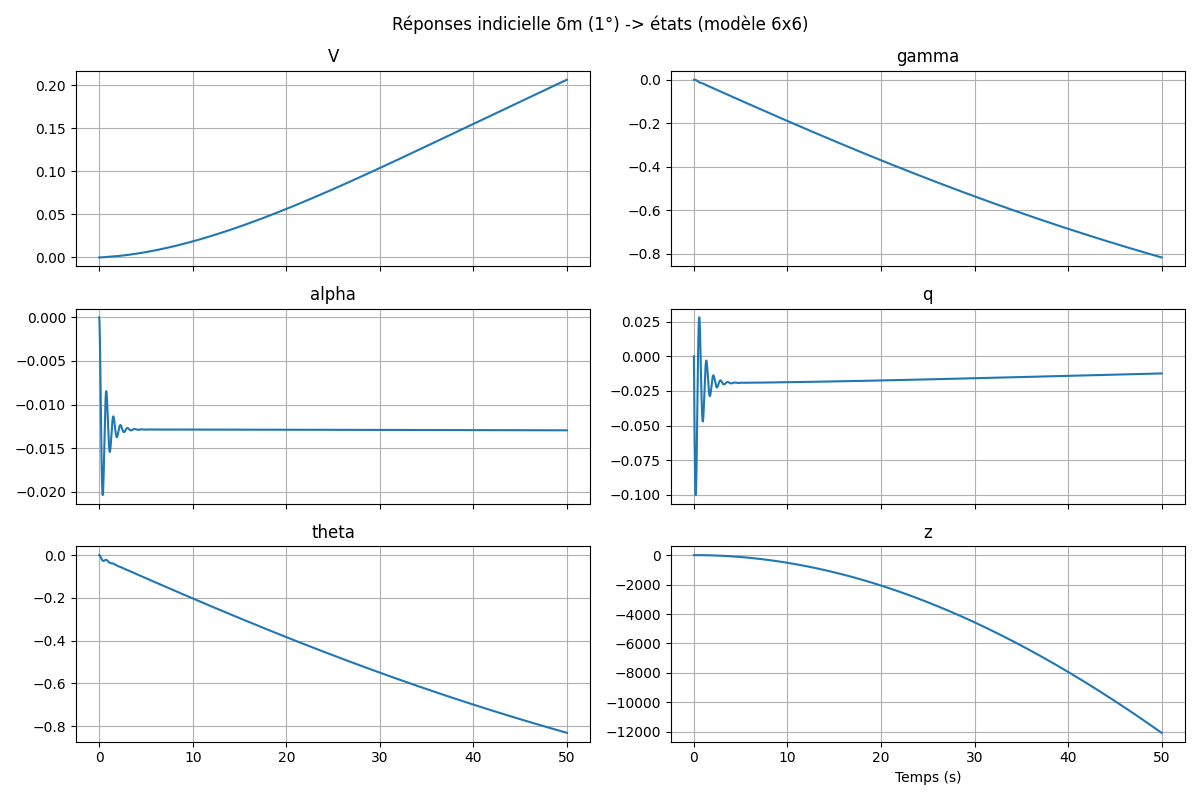

In [28]:
# amplitude de l'échelon sur δm : 1° = 0.01745 rad
delta_step = 1.0 * np.pi / 180.0

t = np.linspace(0, 50, 2000)

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for i, name in enumerate(state_names):
    # sortie = état i uniquement
    Ci = np.zeros((1, 6))
    Ci[0, i] = 1.0
    Di = np.zeros((1, 1))
    sys_i = control.ss(A6, B6, Ci, Di)

    tout, yout = control.step_response(sys_i, T=t)
    yout = np.squeeze(yout) * delta_step  # on applique l'amplitude de l'échelon

    ax = axes[i]
    ax.plot(tout, yout)
    ax.set_title(name)
    ax.grid(True)

axes[-1].set_xlabel("Temps (s)")
fig.suptitle("Réponses indicielle δm (1°) -> états (modèle 6x6)")
plt.tight_layout()
plt.show()


Matrice A et B (taille 5x5)

In [29]:
# Matrice A (5x5) et B (5x1) pour X = (gamma, alpha, q, theta, z)^T
A5 = A6[1:, 1:]   # enlève la première ligne/colonne (V)
B5 = B6[1:, :]    # enlève la première ligne de B

# Matrice de sortie pour q (3e état de [γ, α, q, θ, z])
C_q = np.zeros((1, 5))
C_q[0, 2] = 1.0  
D_q = 0


print("\n===== MATRICE A5 (5x5) =====")
for row in A5:
    print("  ", ["{: .6e}".format(x) for x in row])

print("\n===== MATRICE B5 (5x1) =====")
for row in B5:
    print("  ", ["{: .6e}".format(x) for x in row])

print("\n===== MATRICE C_q (1x5) =====")
print(["{: .6e}".format(x) for x in C_q[0]])

print("\n===== MATRICE D_q (1x1) =====")
print(D_q)


===== MATRICE A5 (5x5) =====
   [' 0.000000e+00', ' 1.954439e+00', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   [' 0.000000e+00', '-1.954439e+00', ' 1.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   [' 0.000000e+00', '-6.941127e+01', '-8.833363e-01', ' 0.000000e+00', ' 0.000000e+00']
   [' 0.000000e+00', ' 0.000000e+00', ' 1.000000e+00', ' 0.000000e+00', ' 0.000000e+00']
   [' 5.492733e+02', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00', ' 0.000000e+00']

===== MATRICE B5 (5x1) =====
   [' 3.346967e-01']
   ['-3.346967e-01']
   ['-5.212704e+01']
   [' 0.000000e+00']
   [' 0.000000e+00']

===== MATRICE C_q (1x5) =====
[' 0.000000e+00', ' 0.000000e+00', ' 1.000000e+00', ' 0.000000e+00', ' 0.000000e+00']

===== MATRICE D_q (1x1) =====
0


Systèmes d’état et pôles (phugoïde / période courte)

In [30]:
state_names_5 = ["gamma", "alpha", "q", "theta", "z"]

# Système complet (sortie = tous les états)
C5_full = np.eye(5)
D5_full = np.zeros((5, 1))
sys5_full = control.ss(A5, B5, C5_full, D5_full)

# Système SISO pour q uniquement
sys5_q = control.ss(A5, B5, C_q, D_q)

print("\n===== PÔLES (VALEURS PROPRES – MODÈLE 5x5) =====")
poles5 = sys5_full.poles()
for i, p in enumerate(poles5):
    print(f"p[{i}] = {p:.6e}")

print("\n===== ANALYSE DES MODES (ω_n, ζ) =====")
modes5 = []
for i, p in enumerate(poles5):
    sigma = np.real(p)
    omega = np.imag(p)
    omega_n = np.sqrt(sigma**2 + omega**2)
    zeta = -sigma / omega_n if omega_n != 0 else np.nan

    modes5.append({"idx": i, "pole": p, "omega_n": omega_n, "zeta": zeta})

    print(f"Mode {i}:")
    print(f"  p = {p:.6e}")
    print(f"  ω_n = {omega_n:.6f} rad/s")
    print(f"  ζ   = {zeta:.6f}")
    print()

# Identification des deux paires complexes : phugoïde (faible ω_n) et période courte (forte ω_n)
complex_modes5 = [m for m in modes5 if abs(np.imag(m["pole"])) > 1e-6]
complex_modes5_sorted = sorted(complex_modes5, key=lambda m: m["omega_n"])

if len(complex_modes5_sorted) >= 4:
    phugoid_modes = complex_modes5_sorted[0:2]      # plus petite fréquence
    short_period_modes = complex_modes5_sorted[-2:] # plus grande fréquence

    print("===== MODE PHUGOÏDE (faible fréquence) =====")
    for m in phugoid_modes:
        print(f"  p = {m['pole']:.6e}, ω_n = {m['omega_n']:.4f}, ζ = {m['zeta']:.4f}")

    print("\n===== MODE PÉRIODE COURTE (haute fréquence) =====")
    for m in short_period_modes:
        print(f"  p = {m['pole']:.6e}, ω_n = {m['omega_n']:.4f}, ζ = {m['zeta']:.4f}")



===== PÔLES (VALEURS PROPRES – MODÈLE 5x5) =====
p[0] = 0.000000e+00+0.000000e+00j
p[1] = 0.000000e+00+0.000000e+00j
p[2] = 0.000000e+00+0.000000e+00j
p[3] = -1.418888e+00+8.314112e+00j
p[4] = -1.418888e+00-8.314112e+00j

===== ANALYSE DES MODES (ω_n, ζ) =====
Mode 0:
  p = 0.000000e+00+0.000000e+00j
  ω_n = 0.000000 rad/s
  ζ   = nan

Mode 1:
  p = 0.000000e+00+0.000000e+00j
  ω_n = 0.000000 rad/s
  ζ   = nan

Mode 2:
  p = 0.000000e+00+0.000000e+00j
  ω_n = 0.000000 rad/s
  ζ   = nan

Mode 3:
  p = -1.418888e+00+8.314112e+00j
  ω_n = 8.434317 rad/s
  ζ   = 0.168228

Mode 4:
  p = -1.418888e+00-8.314112e+00j
  ω_n = 8.434317 rad/s
  ζ   = 0.168228



Représentation d’état par mode (2ᵉ ordre équivalent)

In [31]:
def second_order_ss(omega_n, zeta):
    """
    Renvoie (A,B,C,D) d'un système 2e ordre standard :
    xdot = [0 1; -omega_n^2 -2*zeta*omega_n] x + [0;1] u
    y = [1 0] x
    """
    A = np.array([[0.0, 1.0],
                  [-omega_n**2, -2*zeta*omega_n]])
    B = np.array([[0.0],
                  [1.0]])
    C = np.array([[1.0, 0.0]])
    D = np.array([[0.0]])
    return A, B, C, D

if len(complex_modes5_sorted) >= 4:
    # On prend le premier pôle de chaque paire (les conjugués ont même ω_n, ζ)
    ph_wn = phugoid_modes[0]["omega_n"]
    ph_z  = phugoid_modes[0]["zeta"]
    sp_wn = short_period_modes[0]["omega_n"]
    sp_z  = short_period_modes[0]["zeta"]

    A_ph, B_ph, C_ph, D_ph = second_order_ss(ph_wn, ph_z)
    A_sp, B_sp, C_sp, D_sp = second_order_ss(sp_wn, sp_z)

    sys_ph = control.ss(A_ph, B_ph, C_ph, D_ph)
    sys_sp = control.ss(A_sp, B_sp, C_sp, D_sp)

    print("\n===== MATRICE A DU MODE PHUGOÏDE (2x2) =====")
    print(A_ph)
    print("\n===== MATRICE A DU MODE PÉRIODE COURTE (2x2) =====")
    print(A_sp)

Fonctions de transfert δₘ → chaque variable (modèle 5×5)

In [32]:
# ==== Fonctions de transfert (MIMO) δm -> [γ, α, q, θ, z] ====
G5 = control.ss2tf(sys5_full)  # 5 sorties, 1 entrée

print("\n===== FONCTIONS DE TRANSFERT δm -> état_i (modèle 5x5) =====")
for i, name in enumerate(state_names_5):
    Gi = G5[i, 0]   # sortie i, unique entrée 0
    print(f"\nG_{name}(s) = {name}(s) / δm(s) :")
    print(Gi)



===== FONCTIONS DE TRANSFERT δm -> état_i (modèle 5x5) =====

G_gamma(s) = gamma(s) / δm(s) :
<TransferFunction>: sys[528]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.3347 s^4 + 0.2956 s^3 - 78.65 s^2
  -----------------------------------
      s^5 + 2.838 s^4 + 71.14 s^3

G_alpha(s) = alpha(s) / δm(s) :
<TransferFunction>: sys[528]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[1]']

    -0.3347 s^4 - 52.42 s^3
  ---------------------------
  s^5 + 2.838 s^4 + 71.14 s^3

G_q(s) = q(s) / δm(s) :
<TransferFunction>: sys[528]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[2]']

    -52.13 s^4 - 78.65 s^3
  ---------------------------
  s^5 + 2.838 s^4 + 71.14 s^3

G_theta(s) = theta(s) / δm(s) :
<TransferFunction>: sys[528]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[3]']

    - 52.13 s^3 - 78.65 s^2
  ---------------------------
  s^5 + 2.838 s^4 + 71.14 s^3

G_z(s) = z(s) / δm(s) :
<TransferFunction>: sys[528]$indexed
Inputs (1): ['u[0]']
Outputs (1): ['y[4]']

   + 183.8 

Réponse indicielle δₘ → q (mode période courte dominant)

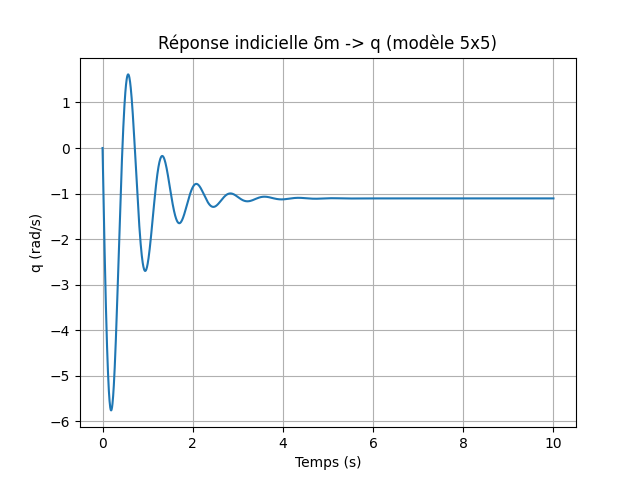

In [33]:
# ===== Réponse indicielle δm -> q =====

t = np.linspace(0, 10, 2000)  # 10 s suffisent pour voir la période courte
t_out, y_out = control.step_response(sys5_q, T=t)
y_out = np.squeeze(y_out)     # (N,) au lieu de (1,N)

plt.figure()
plt.plot(t_out, y_out)
plt.title("Réponse indicielle δm -> q (modèle 5x5)")
plt.xlabel("Temps (s)")
plt.ylabel("q (rad/s)")
plt.grid(True)
plt.show()


Réponses indicielles δₘ → chaque état (γ, α, q, θ, z)

y_out.shape = (5, 3000)


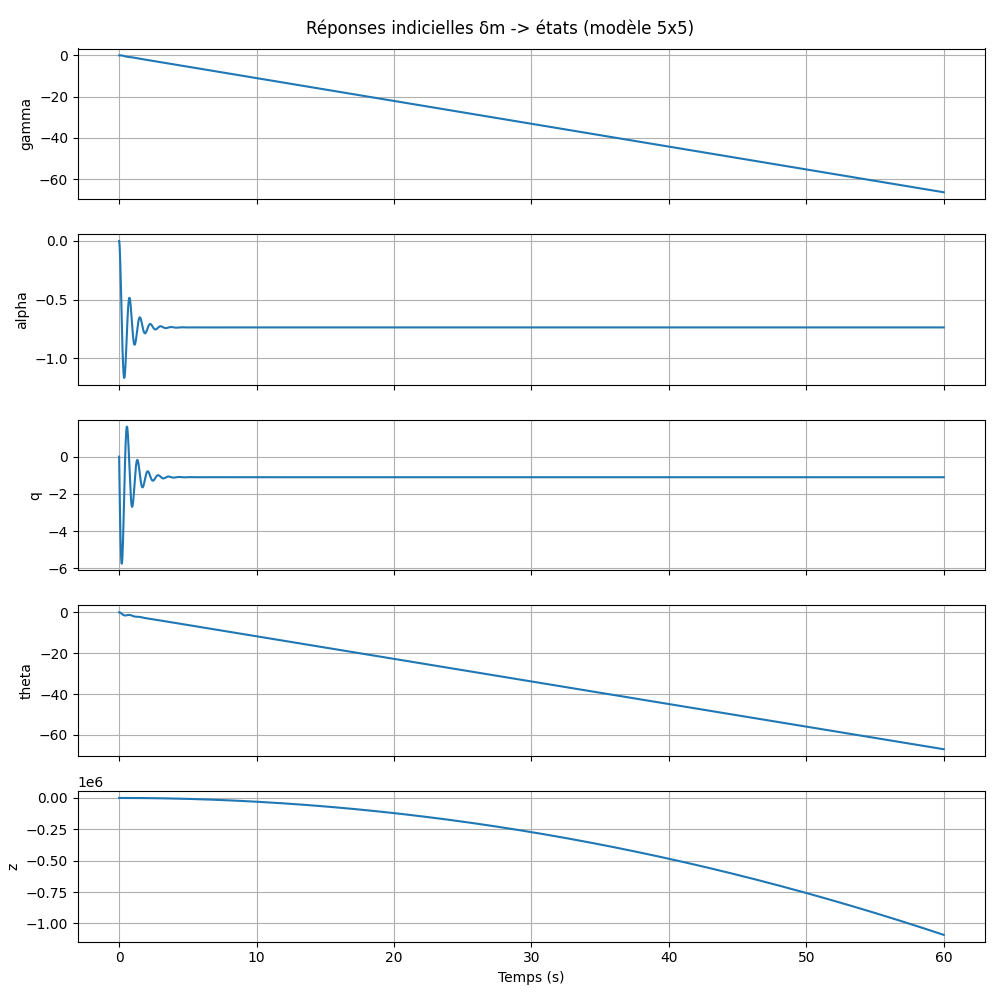

In [34]:
# ===== Réponse indicielle δm -> [γ, α, q, θ, z] =====

t = np.linspace(0, 60, 3000)  # 60 s pour voir aussi la phugoïde
t_out, y_out = control.step_response(sys5_full, T=t)
y_out = np.squeeze(y_out)     # (5,N)

print("y_out.shape =", y_out.shape)  # devrait être (5, N)

fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)

for i, name in enumerate(state_names_5):
    axes[i].plot(t_out, y_out[i, :])
    axes[i].set_ylabel(name)
    axes[i].grid(True)

axes[-1].set_xlabel("Temps (s)")
fig.suptitle("Réponses indicielles δm -> états (modèle 5x5)")
plt.tight_layout()
plt.show()


SYNTHÈSE DU CONTRÔLEUR Q

3 states have been removed from the model


c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\control\rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\control\timeresp.py:1196: RuntimeWarning: overflow encountered in matmul
  xout[:, i] = (Ad @ xout[:, i-1]
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\control\timeresp.py:1198: RuntimeWarning: overflow encountered in matmul
  yout = C @ xout + D @ U
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\ticker.py:2178: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale


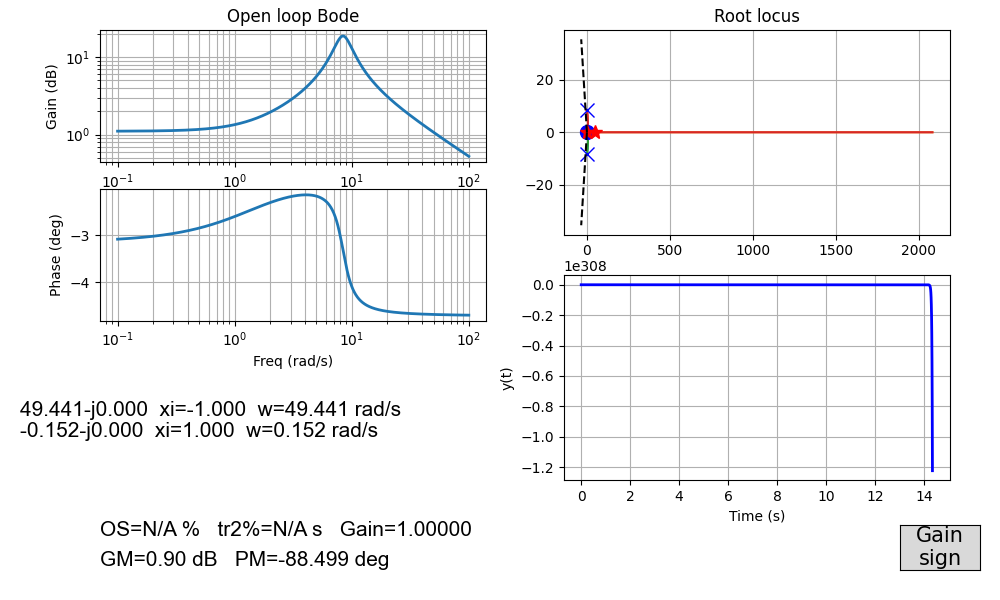

1.0

In [35]:
import sisopy31
sys_q_open_loop = control.ss(A5, B5, C_q, D_q)
sys_q_ol = control.ss2tf(sys_q_open_loop)
sisopy31.sisotool(sys_q_ol)


--- SYNTHÈSE BOUCLE Q (q feedback loop) ---
Gain optimisé Kr: -0.2655
Facteur d'amortissement atteint (xi): 0.5000 (Cible: 0.65)
Pulsation propre (omega_n): 1.0000 rad/s

MATRICE D'ÉTAT EN BOUCLE FERMÉE (Ak_opt):
[[  0.       1.9544   0.0889   0.       0.    ]
 [  0.      -1.9544   0.9111   0.       0.    ]
 [  0.     -69.4113 -14.7231   0.       0.    ]
 [  0.       0.       1.       0.       0.    ]
 [549.2733   0.       0.       0.       0.    ]]

MATRICE DE COMMANDE EN BOUCLE FERMÉE (Bk_opt):
[[-0.0889]
 [ 0.0889]
 [13.8397]
 [-0.    ]
 [-0.    ]]


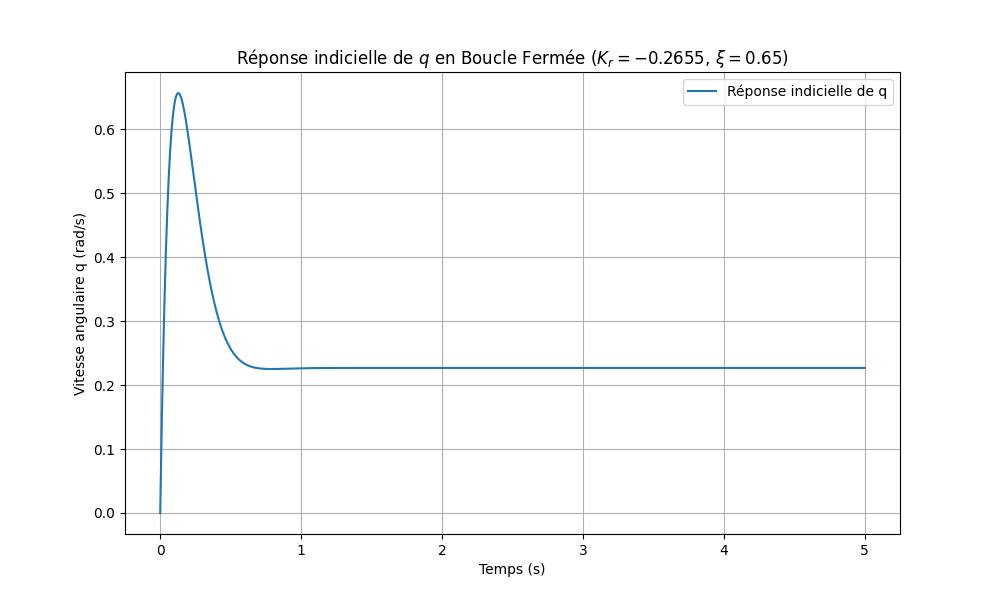

In [36]:
# Objectif: Facteur d'amortissement en boucle fermée xi_cl = 0.65 pour le mode Période Courte.
xi_target_q = 0.65
Kr_optimized = -0.2655

# Initialiser les variables avant la boucle pour éviter NameError
xi_final_q = 0.5
omega_n_final_q = 1.0
poles_cl_short_period = -0.5 + 1.0j

# Matrice de sortie pour q (q est la 3ème variable d'état, index 2)
C_q = np.array([[0.0, 0.0, 1.0, 0.0, 0.0]])
D_q = np.zeros((1, 1))

# Recherche du gain Kr qui donne xi_cl = 0.65 (balayage)
Kr_list = np.linspace(0.1, 5.0, 500) 
min_diff_q = float('inf')

for Kr_test in Kr_list:
    # Matrices en Boucle Fermée pour q: Ak = A - Kr * B * Cq
    Ak = A5 - Kr_test * B5 @ C_q
    
    sys_cl_q_analysis = control.ss(Ak, B5, C_q, D_q)
    poles_cl = control.poles(sys_cl_q_analysis)
    
    poles_complex = [p for p in poles_cl if np.imag(p) != 0.0 and np.real(p) < 0]
    if poles_complex:
        p_cl = sorted(poles_complex, key=np.abs, reverse=True)[0]
        p_real = np.real(p_cl)
        omega_n = np.abs(p_cl)
        xi = -p_real / omega_n
        
        diff = np.abs(xi - xi_target_q)
        
        if diff < min_diff_q:
            min_diff_q = diff
            Kr_optimized = Kr_test
            xi_final_q = xi
            omega_n_final_q = omega_n
            poles_cl_short_period = p_cl
            
# Matrice d'état finale en boucle fermée pour Kr
Ak_opt = A5 - Kr_optimized * B5 @ C_q
Bk_opt = Kr_optimized * B5
sys_cl_q_final = control.ss(Ak_opt, Bk_opt, C_q, D_q)
poles_cl_final = control.poles(sys_cl_q_final)

# Affichage des résultats
print("\n--- SYNTHÈSE BOUCLE Q (q feedback loop) ---")
print(f"Gain optimisé Kr: {Kr_optimized:.4f}")
print(f"Facteur d'amortissement atteint (xi): {xi_final_q:.4f} (Cible: {xi_target_q})")
print(f"Pulsation propre (omega_n): {omega_n_final_q:.4f} rad/s")
print("\nMATRICE D'ÉTAT EN BOUCLE FERMÉE (Ak_opt):")
print(Ak_opt.round(4))
print("\nMATRICE DE COMMANDE EN BOUCLE FERMÉE (Bk_opt):")
print(Bk_opt.round(4))

# Tracé de la réponse indicielle
T_sim_q = 5.0 # 5s suffisent pour la période courte
T_out_q, Y_out_q = control.step_response(sys_cl_q_final, T=np.linspace(0, T_sim_q, 500))
Y_out_q = np.squeeze(Y_out_q)  # Reshape to 1D array

plt.figure(figsize=(10, 6))
plt.plot(T_out_q, Y_out_q, label='Réponse indicielle de q')
plt.title(f'Réponse indicielle de $q$ en Boucle Fermée ($K_r = {Kr_optimized:.4f}$, $\\xi=0.65$)')
plt.xlabel('Temps (s)'); plt.ylabel('Vitesse angulaire q (rad/s)')
plt.grid(); plt.legend(); plt.show()


SYNTHÈSE DU CONTRÔLEUR GAMMA


--- SYNTHÈSE BOUCLE GAMMA (gamma feedback loop) ---
Recherche de K_gamma (D1<=5%, xi>=0.5, min tr5%)...
Gain optimisé K_gamma: 8.7600
Dépassement D1: 0.00% (Cible: <=5%)
Temps de réponse (t_r5%): 1.00 s

MATRICE D'ÉTAT EN BOUCLE FERMÉE (A_gamma_opt):
[[   0.7784    1.9544    0.0889    0.        0.    ]
 [  -0.7784   -1.9544    0.9111    0.        0.    ]
 [-121.236   -69.4113  -14.7231    0.        0.    ]
 [   0.        0.        1.        0.        0.    ]
 [ 549.2733    0.        0.        0.        0.    ]]

MATRICE DE COMMANDE EN BOUCLE FERMÉE (B_gamma_opt):
[[ -0.7784]
 [  0.7784]
 [121.236 ]
 [ -0.    ]
 [ -0.    ]]


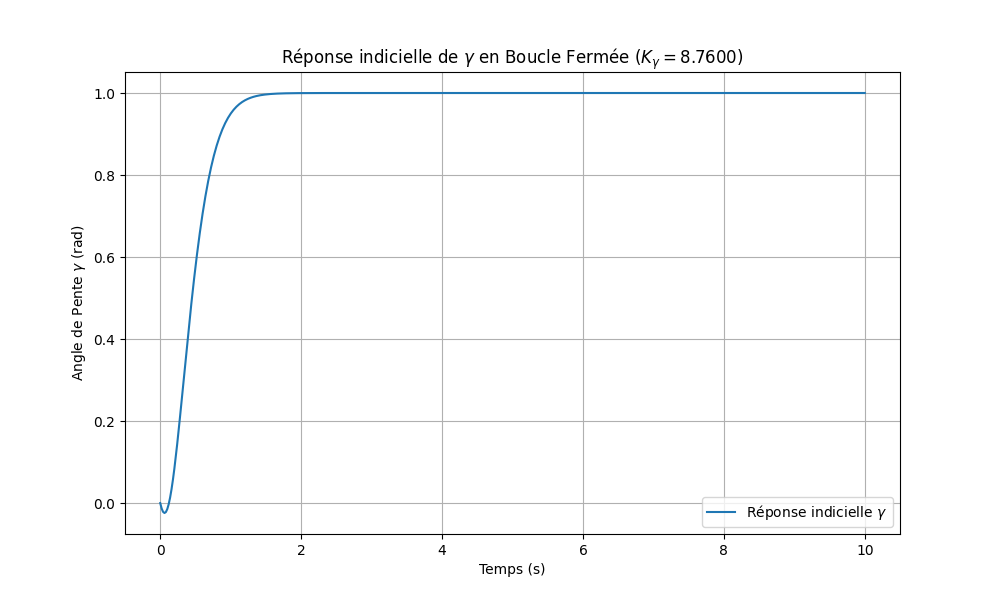


Bloc 1 (Contrôleur Gamma) exécuté.
--------------------------------------------------


In [37]:
# Output matrix for gamma (gamma est la 1ère variable d'état, index 0)
C_gamma = np.array([[1.0, 0.0, 0.0, 0.0, 0.0]])
D_gamma = np.zeros((1, 1))

# Objectives (Page 30): Overshoot D1 <= 5%, Settling time t_r5% minimized, xi >= 0.5.
D1_target_gamma = 0.05
xi_min_gamma = 0.5
Kr_gamma_optimized = 0.0
min_tr5_gamma = float('inf')
final_overshoot_gamma = 1.0 
final_tr5_gamma = float('inf')
A_gamma_opt = Ak_opt # Initialisation avec Ak_opt
B_gamma_opt = Bk_opt # Initialisation avec Bk_opt

# Search for the optimal gain K_gamma
K_gamma_list = np.linspace(0.01, 10.0, 1000)

print("\n--- SYNTHÈSE BOUCLE GAMMA (gamma feedback loop) ---")
print("Recherche de K_gamma (D1<=5%, xi>=0.5, min tr5%)...")

for K_gamma_test in K_gamma_list:
    # Matrices en Boucle Fermée pour gamma: 
    A_gamma = Ak_opt - Bk_opt @ (K_gamma_test * C_gamma)
    B_gamma = Bk_opt * K_gamma_test
    
    sys_cl_gamma = control.ss(A_gamma, B_gamma, C_gamma, D_gamma)
    
    # 1. Vérification des pôles et du facteur d'amortissement (xi >= 0.5)
    poles_cl = control.poles(sys_cl_gamma)
    is_damped_enough = True
    for p in poles_cl:
        if np.imag(p) != 0.0:
            if np.real(p) >= 0:
                is_damped_enough = False
                break
            wn = np.abs(p)
            xi = -np.real(p) / wn
            if xi < xi_min_gamma:
                is_damped_enough = False
                break
    
    if is_damped_enough:
        
        # 2. Calcul des performances transitoires (D1 et tr5%)
        T_step, Y_step = control.step_response(sys_cl_gamma, T=np.linspace(0, 100, 500))
        steady_state_value = Y_step[-1]
        
        if abs(steady_state_value) > 1e-6:
            peak_value = np.max(Y_step)
            overshoot_D1 = (peak_value - steady_state_value) / steady_state_value
            tolerance = 0.05 * abs(steady_state_value)
            upper_bound = steady_state_value + tolerance
            lower_bound = steady_state_value - tolerance
            tr5 = T_step[-1]
            for k in range(len(Y_step) - 1, 0, -1):
                if not (lower_bound <= Y_step[k] <= upper_bound):
                    tr5 = T_step[k+1] if k+1 < len(T_step) else T_step[k]
                    break
        else:
             overshoot_D1 = 0 
             tr5 = float('inf')
                
        # 3. Optimisation : Choisir le K_gamma qui minimise tr5% tout en respectant D1
        if overshoot_D1 <= D1_target_gamma:
            if tr5 < min_tr5_gamma:
                min_tr5_gamma = tr5
                Kr_gamma_optimized = K_gamma_test
                final_overshoot_gamma = overshoot_D1
                final_tr5_gamma = tr5
                A_gamma_opt = A_gamma 
                B_gamma_opt = B_gamma
                
# Construction du système final pour K_gamma optimisé
sys_cl_gamma_final = control.ss(A_gamma_opt, B_gamma_opt, C_gamma, D_gamma)

# Affichage des résultats
print(f"Gain optimisé K_gamma: {Kr_gamma_optimized:.4f}")
print(f"Dépassement D1: {final_overshoot_gamma*100:.2f}% (Cible: <=5%)")
print(f"Temps de réponse (t_r5%): {final_tr5_gamma:.2f} s")

print("\nMATRICE D'ÉTAT EN BOUCLE FERMÉE (A_gamma_opt):")
print(A_gamma_opt.round(4))
print("\nMATRICE DE COMMANDE EN BOUCLE FERMÉE (B_gamma_opt):")
print(B_gamma_opt.round(4))

# Tracé de la réponse indicielle
T_sim_gamma = 10.0 
T_out_gamma, Y_out_gamma = control.step_response(sys_cl_gamma_final, T=np.linspace(0, T_sim_gamma, 500))
Y_out_gamma = np.squeeze(Y_out_gamma) 

plt.figure(figsize=(10, 6))
plt.plot(T_out_gamma, Y_out_gamma, label='Réponse indicielle $\\gamma$')
plt.title(f'Réponse indicielle de $\\gamma$ en Boucle Fermée ($K_\\gamma={Kr_gamma_optimized:.4f}$)')
plt.xlabel('Temps (s)'); plt.ylabel('Angle de Pente $\\gamma$ (rad)')
plt.grid(); plt.legend(); plt.show()

print("\nBloc 1 (Contrôleur Gamma) exécuté.")
print("-" * 50)

SYNTHÈSE DU CONTRÔLEUR Z (Altitude)


--- SYNTHÈSE BOUCLE Z (z feedback loop) ---
Recherche de K_z (D1<=5%, xi>=0.5, min tr5%) avec capteur...
Gain optimisé K_z: 0.0000
Dépassement D1: 100.00% (Cible: <=5%)
Temps de réponse (t_r5%): inf s

MATRICE D'ÉTAT EN BOUCLE FERMÉE (A_cl_z_opt):
[[   0.7784    1.9544    0.0889    0.        0.        0.    ]
 [  -0.7784   -1.9544    0.9111    0.        0.        0.    ]
 [-121.236   -69.4113  -14.7231    0.        0.        0.    ]
 [   0.        0.        1.        0.        0.        0.    ]
 [ 549.2733    0.        0.        0.        0.        0.    ]
 [   0.        0.        0.        0.        1.5385   -1.5385]]

MATRICE DE COMMANDE EN BOUCLE FERMÉE (B_cl_z_opt):
[[-0.]
 [ 0.]
 [ 0.]
 [-0.]
 [-0.]
 [ 0.]]


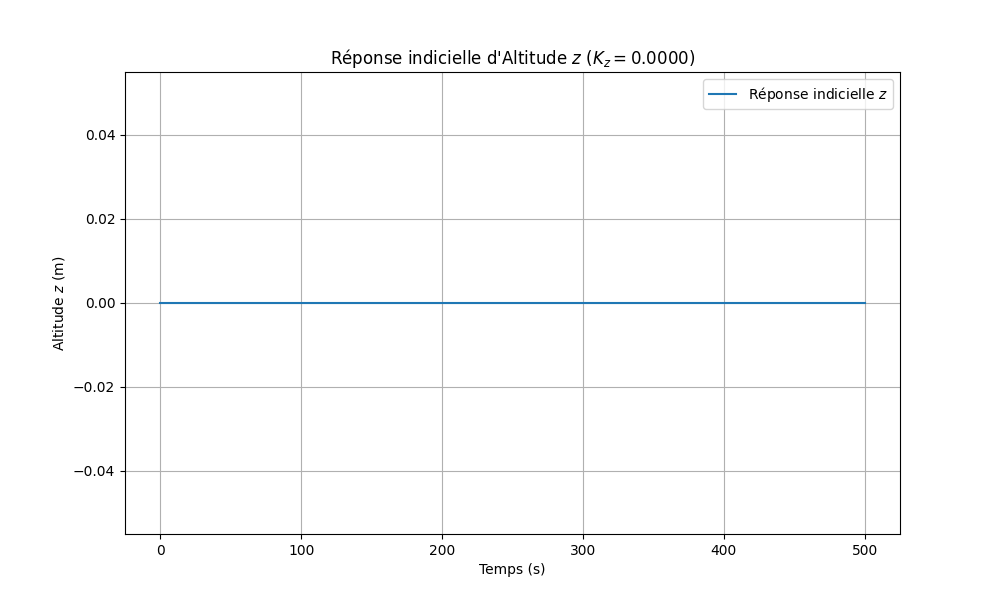


Bloc 3 (Contrôleur Z) exécuté.
--------------------------------------------------


In [38]:
# Output matrix for z (z est la 5ème variable d'état, index 4)
C_z = np.array([[0.0, 0.0, 0.0, 0.0, 1.0]])
D_z = np.zeros((1, 1))

# Modèle du capteur d'altitude: G_sensor(s) = 1 / (tau_alt_sensor * s + 1)
tau_alt_sensor = 0.65 

# Système augmenté X_aug = (gamma, alpha, q, theta, z, z_sensor_state)T (6x1)
A_aug = np.zeros((6, 6))
B_aug = np.zeros((6, 1))

# Dynamique de l'avion (5x5)
A_aug[:5, :5] = A_gamma_opt
B_aug[:5, 0] = B_gamma_opt.flatten()

# Dynamique du capteur (z_s est la sortie mesurée)
A_aug[5, 4] = 1.0 / tau_alt_sensor # Terme pour z
A_aug[5, 5] = -1.0 / tau_alt_sensor # Terme pour z_s

# Matrice de sortie mesurée: z_s (index 5 du système augmenté)
C_z_s = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]])
D_z_s = np.zeros((1, 1))


# Objectifs (Page 32 du PT): Dépassement D1 <= 5%, Temps de réponse tr5% minimisé, xi >= 0.5.
D1_target_z = 0.05
xi_min_z = 0.5
Kr_z_optimized = 0.0
min_tr5_z = float('inf')
final_overshoot_z = 1.0
final_tr5_z = float('inf')
final_poles_z = None

# Recherche du gain K_z (balayage)
K_z_list = np.linspace(0.001, 0.2, 500) # Kz est généralement un petit gain

print("\n--- SYNTHÈSE BOUCLE Z (z feedback loop) ---")
print("Recherche de K_z (D1<=5%, xi>=0.5, min tr5%) avec capteur...")
# 

for K_z_test in K_z_list:
    # Boucle Fermée sur z_s: A_cl_z = A_aug - B_aug * Kz * C_z_s
    A_cl_z = A_aug - B_aug @ (K_z_test * C_z_s)
    B_cl_z = B_aug * K_z_test
    
    # Le système en boucle fermée donne en sortie z (index 4 du système augmenté)
    C_z_aug = np.array([[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]]) 
    sys_cl_z = control.ss(A_cl_z, B_cl_z, C_z_aug, np.zeros((1, 1)))
    
    # 1. Vérification des pôles et du facteur d'amortissement (xi >= 0.5)
    poles_cl = control.poles(sys_cl_z)
    is_damped_enough = True
    for p in poles_cl:
        if np.imag(p) != 0.0:
            if np.real(p) >= 0: 
                is_damped_enough = False
                break
            wn = np.abs(p)
            xi = -np.real(p) / wn
            if xi < xi_min_z:
                is_damped_enough = False
                break
    
    if is_damped_enough:
        # 2. Calcul des performances transitoires (D1 et tr5%)
        T_step, Y_step = control.step_response(sys_cl_z, T=np.linspace(0, 500, 500))
        
        steady_state_value = Y_step[-1]
        
        if abs(steady_state_value) > 1e-6:
             peak_value = np.max(Y_step)
             overshoot_D1 = (peak_value - steady_state_value) / steady_state_value
             
             tolerance = 0.05 * abs(steady_state_value)
             upper_bound = steady_state_value + tolerance
             lower_bound = steady_state_value - tolerance
             
             tr5 = T_step[-1]
             for k in range(len(Y_step) - 1, 0, -1):
                 if not (lower_bound <= Y_step[k] <= upper_bound):
                     tr5 = T_step[k+1] if k+1 < len(T_step) else T_step[k]
                     break
        else:
             overshoot_D1 = 0 
             tr5 = float('inf')


        # 3. Optimisation : Choisir le K_z qui minimise tr5% tout en respectant D1
        if overshoot_D1 <= D1_target_z:
            if tr5 < min_tr5_z:
                min_tr5_z = tr5
                Kr_z_optimized = K_z_test
                final_overshoot_z = overshoot_D1
                final_tr5_z = tr5
                final_poles_z = poles_cl
                
# Construction du système final pour K_z optimisé
A_cl_z_opt = A_aug - B_aug @ (Kr_z_optimized * C_z_s)
B_cl_z_opt = B_aug * Kr_z_optimized

# Affichage des résultats
print(f"Gain optimisé K_z: {Kr_z_optimized:.4f}")
print(f"Dépassement D1: {final_overshoot_z*100:.2f}% (Cible: <=5%)")
print(f"Temps de réponse (t_r5%): {final_tr5_z:.2f} s")

print("\nMATRICE D'ÉTAT EN BOUCLE FERMÉE (A_cl_z_opt):")
print(A_cl_z_opt.round(4))
print("\nMATRICE DE COMMANDE EN BOUCLE FERMÉE (B_cl_z_opt):")
print(B_cl_z_opt.round(4))

# Tracé de la réponse indicielle
sys_cl_z_final = control.ss(A_cl_z_opt, B_cl_z_opt, C_z_aug, D_z_s)
T_sim_z = 500.0
T_out_z, Y_out_z = control.step_response(sys_cl_z_final, T=np.linspace(0, T_sim_z, 1000))
Y_out_z = np.squeeze(Y_out_z)

plt.figure(figsize=(10, 6))
plt.plot(T_out_z, Y_out_z, label='Réponse indicielle $z$')
plt.title(f'Réponse indicielle d\'Altitude $z$ ($K_z={Kr_z_optimized:.4f}$)')
plt.xlabel('Temps (s)'); plt.ylabel('Altitude $z$ (m)')
plt.grid(); plt.legend(); plt.show()

print("\nBloc 3 (Contrôleur Z) exécuté.")
print("-" * 50)

SYNTHÈSE DU CONTRÔLEUR GAMMA


--- SYNTHÈSE BOUCLE GAMMA (gamma feedback loop) ---
Recherche de K_gamma (D1<=5%, xi>=0.5, min tr5%)...
Gain optimisé K_gamma: 8.7600
Dépassement D1: 0.00% (Cible: <=5%)
Temps de réponse (t_r5%): 1.00 s

MATRICE D'ÉTAT EN BOUCLE FERMÉE (A_gamma_opt):
[[   0.7784    1.9544    0.0889    0.        0.    ]
 [  -0.7784   -1.9544    0.9111    0.        0.    ]
 [-121.236   -69.4113  -14.7231    0.        0.    ]
 [   0.        0.        1.        0.        0.    ]
 [ 549.2733    0.        0.        0.        0.    ]]

MATRICE DE COMMANDE EN BOUCLE FERMÉE (B_gamma_opt):
[[ -0.7784]
 [  0.7784]
 [121.236 ]
 [ -0.    ]
 [ -0.    ]]


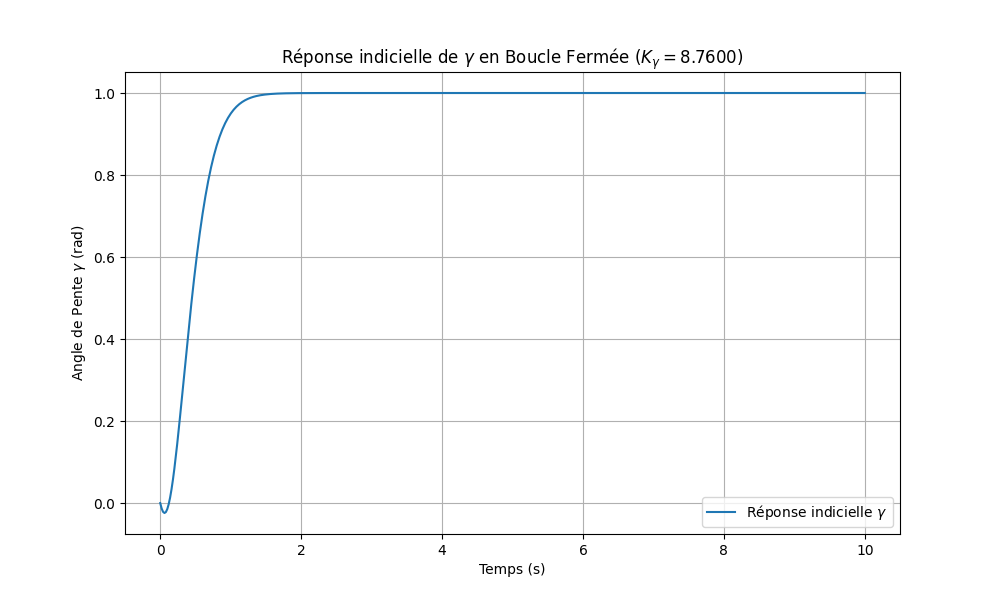


Bloc 1 (Contrôleur Gamma) exécuté.
--------------------------------------------------


In [39]:
# Output matrix for gamma (gamma est la 1ère variable d'état, index 0)
C_gamma = np.array([[1.0, 0.0, 0.0, 0.0, 0.0]])
D_gamma = np.zeros((1, 1))

# Objectives (Page 30): Overshoot D1 <= 5%, Settling time t_r5% minimized, xi >= 0.5.
D1_target_gamma = 0.05
xi_min_gamma = 0.5
Kr_gamma_optimized = 0.0
min_tr5_gamma = float('inf')
final_overshoot_gamma = 1.0 
final_tr5_gamma = float('inf')
A_gamma_opt = Ak_opt # Initialisation avec Ak_opt
B_gamma_opt = Bk_opt # Initialisation avec Bk_opt

# Search for the optimal gain K_gamma
K_gamma_list = np.linspace(0.01, 10.0, 1000)

print("\n--- SYNTHÈSE BOUCLE GAMMA (gamma feedback loop) ---")
print("Recherche de K_gamma (D1<=5%, xi>=0.5, min tr5%)...")

for K_gamma_test in K_gamma_list:
    # Matrices en Boucle Fermée pour gamma: 
    A_gamma = Ak_opt - Bk_opt @ (K_gamma_test * C_gamma)
    B_gamma = Bk_opt * K_gamma_test
    
    sys_cl_gamma = control.ss(A_gamma, B_gamma, C_gamma, D_gamma)
    
    # 1. Vérification des pôles et du facteur d'amortissement (xi >= 0.5)
    poles_cl = control.poles(sys_cl_gamma)
    is_damped_enough = True
    for p in poles_cl:
        if np.imag(p) != 0.0:
            if np.real(p) >= 0:
                is_damped_enough = False
                break
            wn = np.abs(p)
            xi = -np.real(p) / wn
            if xi < xi_min_gamma:
                is_damped_enough = False
                break
    
    if is_damped_enough:
        
        # 2. Calcul des performances transitoires (D1 et tr5%)
        T_step, Y_step = control.step_response(sys_cl_gamma, T=np.linspace(0, 100, 500))
        steady_state_value = Y_step[-1]
        
        if abs(steady_state_value) > 1e-6:
            peak_value = np.max(Y_step)
            overshoot_D1 = (peak_value - steady_state_value) / steady_state_value
            tolerance = 0.05 * abs(steady_state_value)
            upper_bound = steady_state_value + tolerance
            lower_bound = steady_state_value - tolerance
            tr5 = T_step[-1]
            for k in range(len(Y_step) - 1, 0, -1):
                if not (lower_bound <= Y_step[k] <= upper_bound):
                    tr5 = T_step[k+1] if k+1 < len(T_step) else T_step[k]
                    break
        else:
             overshoot_D1 = 0 
             tr5 = float('inf')
                
        # 3. Optimisation : Choisir le K_gamma qui minimise tr5% tout en respectant D1
        if overshoot_D1 <= D1_target_gamma:
            if tr5 < min_tr5_gamma:
                min_tr5_gamma = tr5
                Kr_gamma_optimized = K_gamma_test
                final_overshoot_gamma = overshoot_D1
                final_tr5_gamma = tr5
                A_gamma_opt = A_gamma 
                B_gamma_opt = B_gamma
                
# Construction du système final pour K_gamma optimisé
sys_cl_gamma_final = control.ss(A_gamma_opt, B_gamma_opt, C_gamma, D_gamma)

# Affichage des résultats
print(f"Gain optimisé K_gamma: {Kr_gamma_optimized:.4f}")
print(f"Dépassement D1: {final_overshoot_gamma*100:.2f}% (Cible: <=5%)")
print(f"Temps de réponse (t_r5%): {final_tr5_gamma:.2f} s")

print("\nMATRICE D'ÉTAT EN BOUCLE FERMÉE (A_gamma_opt):")
print(A_gamma_opt.round(4))
print("\nMATRICE DE COMMANDE EN BOUCLE FERMÉE (B_gamma_opt):")
print(B_gamma_opt.round(4))

# Tracé de la réponse indicielle
T_sim_gamma = 10.0 
T_out_gamma, Y_out_gamma = control.step_response(sys_cl_gamma_final, T=np.linspace(0, T_sim_gamma, 500))
Y_out_gamma = np.squeeze(Y_out_gamma) 

plt.figure(figsize=(10, 6))
plt.plot(T_out_gamma, Y_out_gamma, label='Réponse indicielle $\\gamma$')
plt.title(f'Réponse indicielle de $\\gamma$ en Boucle Fermée ($K_\\gamma={Kr_gamma_optimized:.4f}$)')
plt.xlabel('Temps (s)'); plt.ylabel('Angle de Pente $\\gamma$ (rad)')
plt.grid(); plt.legend(); plt.show()

print("\nBloc 1 (Contrôleur Gamma) exécuté.")
print("-" * 50)

SYNTHÈSE DU CONTRÔLEUR Z (Altitude)


--- SYNTHÈSE BOUCLE Z (z feedback loop) ---
Recherche de K_z (D1<=5%, xi>=0.5, min tr5%) avec capteur...
Gain optimisé K_z: 0.0000
Dépassement D1: 100.00% (Cible: <=5%)
Temps de réponse (t_r5%): inf s

MATRICE D'ÉTAT EN BOUCLE FERMÉE (A_cl_z_opt):
[[   0.7784    1.9544    0.0889    0.        0.        0.    ]
 [  -0.7784   -1.9544    0.9111    0.        0.        0.    ]
 [-121.236   -69.4113  -14.7231    0.        0.        0.    ]
 [   0.        0.        1.        0.        0.        0.    ]
 [ 549.2733    0.        0.        0.        0.        0.    ]
 [   0.        0.        0.        0.        1.5385   -1.5385]]

MATRICE DE COMMANDE EN BOUCLE FERMÉE (B_cl_z_opt):
[[-0.]
 [ 0.]
 [ 0.]
 [-0.]
 [-0.]
 [ 0.]]


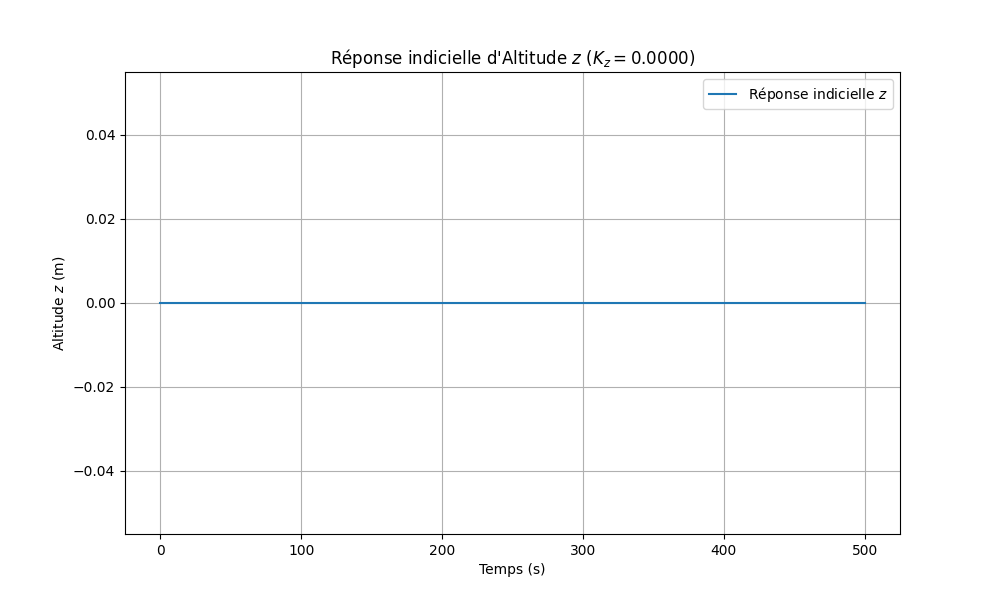


Bloc 3 (Contrôleur Z) exécuté.
--------------------------------------------------


In [40]:
# Output matrix for z (z est la 5ème variable d'état, index 4)
C_z = np.array([[0.0, 0.0, 0.0, 0.0, 1.0]])
D_z = np.zeros((1, 1))

# Modèle du capteur d'altitude: G_sensor(s) = 1 / (tau_alt_sensor * s + 1)
tau_alt_sensor = 0.65 

# Système augmenté X_aug = (gamma, alpha, q, theta, z, z_sensor_state)T (6x1)
A_aug = np.zeros((6, 6))
B_aug = np.zeros((6, 1))

# Dynamique de l'avion (5x5)
A_aug[:5, :5] = A_gamma_opt
B_aug[:5, 0] = B_gamma_opt.flatten()

# Dynamique du capteur (z_s est la sortie mesurée)
A_aug[5, 4] = 1.0 / tau_alt_sensor # Terme pour z
A_aug[5, 5] = -1.0 / tau_alt_sensor # Terme pour z_s

# Matrice de sortie mesurée: z_s (index 5 du système augmenté)
C_z_s = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]])
D_z_s = np.zeros((1, 1))


# Objectifs (Page 32 du PT): Dépassement D1 <= 5%, Temps de réponse tr5% minimisé, xi >= 0.5.
D1_target_z = 0.05
xi_min_z = 0.5
Kr_z_optimized = 0.0
min_tr5_z = float('inf')
final_overshoot_z = 1.0
final_tr5_z = float('inf')
final_poles_z = None

# Recherche du gain K_z (balayage)
K_z_list = np.linspace(0.001, 0.2, 500) # Kz est généralement un petit gain

print("\n--- SYNTHÈSE BOUCLE Z (z feedback loop) ---")
print("Recherche de K_z (D1<=5%, xi>=0.5, min tr5%) avec capteur...")
# 

for K_z_test in K_z_list:
    # Boucle Fermée sur z_s: A_cl_z = A_aug - B_aug * Kz * C_z_s
    A_cl_z = A_aug - B_aug @ (K_z_test * C_z_s)
    B_cl_z = B_aug * K_z_test
    
    # Le système en boucle fermée donne en sortie z (index 4 du système augmenté)
    C_z_aug = np.array([[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]]) 
    sys_cl_z = control.ss(A_cl_z, B_cl_z, C_z_aug, np.zeros((1, 1)))
    
    # 1. Vérification des pôles et du facteur d'amortissement (xi >= 0.5)
    poles_cl = control.poles(sys_cl_z)
    is_damped_enough = True
    for p in poles_cl:
        if np.imag(p) != 0.0:
            if np.real(p) >= 0: 
                is_damped_enough = False
                break
            wn = np.abs(p)
            xi = -np.real(p) / wn
            if xi < xi_min_z:
                is_damped_enough = False
                break
    
    if is_damped_enough:
        # 2. Calcul des performances transitoires (D1 et tr5%)
        T_step, Y_step = control.step_response(sys_cl_z, T=np.linspace(0, 500, 500))
        
        steady_state_value = Y_step[-1]
        
        if abs(steady_state_value) > 1e-6:
             peak_value = np.max(Y_step)
             overshoot_D1 = (peak_value - steady_state_value) / steady_state_value
             
             tolerance = 0.05 * abs(steady_state_value)
             upper_bound = steady_state_value + tolerance
             lower_bound = steady_state_value - tolerance
             
             tr5 = T_step[-1]
             for k in range(len(Y_step) - 1, 0, -1):
                 if not (lower_bound <= Y_step[k] <= upper_bound):
                     tr5 = T_step[k+1] if k+1 < len(T_step) else T_step[k]
                     break
        else:
             overshoot_D1 = 0 
             tr5 = float('inf')


        # 3. Optimisation : Choisir le K_z qui minimise tr5% tout en respectant D1
        if overshoot_D1 <= D1_target_z:
            if tr5 < min_tr5_z:
                min_tr5_z = tr5
                Kr_z_optimized = K_z_test
                final_overshoot_z = overshoot_D1
                final_tr5_z = tr5
                final_poles_z = poles_cl
                
# Construction du système final pour K_z optimisé
A_cl_z_opt = A_aug - B_aug @ (Kr_z_optimized * C_z_s)
B_cl_z_opt = B_aug * Kr_z_optimized

# Affichage des résultats
print(f"Gain optimisé K_z: {Kr_z_optimized:.4f}")
print(f"Dépassement D1: {final_overshoot_z*100:.2f}% (Cible: <=5%)")
print(f"Temps de réponse (t_r5%): {final_tr5_z:.2f} s")

print("\nMATRICE D'ÉTAT EN BOUCLE FERMÉE (A_cl_z_opt):")
print(A_cl_z_opt.round(4))
print("\nMATRICE DE COMMANDE EN BOUCLE FERMÉE (B_cl_z_opt):")
print(B_cl_z_opt.round(4))

# Tracé de la réponse indicielle
sys_cl_z_final = control.ss(A_cl_z_opt, B_cl_z_opt, C_z_aug, D_z_s)
T_sim_z = 500.0
T_out_z, Y_out_z = control.step_response(sys_cl_z_final, T=np.linspace(0, T_sim_z, 1000))
Y_out_z = np.squeeze(Y_out_z)

plt.figure(figsize=(10, 6))
plt.plot(T_out_z, Y_out_z, label='Réponse indicielle $z$')
plt.title(f'Réponse indicielle d\'Altitude $z$ ($K_z={Kr_z_optimized:.4f}$)')
plt.xlabel('Temps (s)'); plt.ylabel('Altitude $z$ (m)')
plt.grid(); plt.legend(); plt.show()

print("\nBloc 3 (Contrôleur Z) exécuté.")
print("-" * 50)